# Análisis Comparativo: Monotributo vs. Responsable Inscripto
## Costo Fiscal Total — Argentina 2026 (1er Semestre)

### Objetivo
Comparar el costo fiscal real de pertenecer al régimen de **Monotributo** frente al régimen de **Responsable Inscripto (RI)** para dos escenarios de facturación:
- **Escenario H**: Máxima facturación posible dentro de la Categoría H del Monotributo
- **Escenario K**: Máxima facturación posible dentro de la Categoría K del Monotributo

### Supuestos generales
- Actividad: **prestación de servicios** (no venta de cosas muebles)
- Facturación al **máximo permitido** en cada categoría
- Clientes **Responsables Inscriptos** (IVA neutro para el prestador)
- Profesional **soltero, sin cargas de familia**
- **Se excluye** del análisis el costo de obra social (puede redirigirse a prepaga)
- Costos profesionales deducibles en RI: **20% de la facturación bruta**
- Honorarios contador en Monotributo: **$55.000/mes**
- Honorarios contador en RI: estimado según complejidad del régimen

### Fuentes
- [ARCA (ex AFIP) — Categorías Monotributo](https://www.afip.gob.ar/monotributo/categorias.asp)
- [Contablix — Tabla completa Feb 2026](https://contablix.ar/monotributo-categorias-2026/)
- [ARCA — Autónomos categorías y aportes](https://www.arca.gob.ar/autonomos/categorias-y-aportes/2026.asp)
- [Ignacio Online — Autónomos 2026 valores vigentes desde enero](https://www.ignacioonline.com.ar/autonomos-2026-valores-vigentes-desde-enero/)
- [Contablix — Responsable Inscripto guía 2026](https://contablix.ar/blog/responsable-inscripto-guia-definitiva-impuestos/)
- [iProfesional — Ganancias 2026 escala y deducciones](https://www.iprofesional.com/impuestos/446080-ganancias-2026-nuevos-valores-de-deducciones-escala-y-piso-salarial)
- [Jorge Vega — Autónomos enero 2026](https://jorgevega.com.ar/laboral/419-autonomos-aportes-categorias-2026-enero.html)
- [Tributosimple — Monotributo vigente](https://tributosimple.com/categorias-del-monotributo-vigentes/)

> **Vigencia:** Valores del 1er semestre 2026 (actualización feb 2026, variación IPC 2do semestre 2025: +14,29%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ─────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────

def fmt_pesos(v):
    """Format a number as Argentine pesos."""
    return f'${v:>15,.0f}'

def fmt_pct(v):
    return f'{v:.2f}%'

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Parámetros del Monotributo (Feb 2026, servicios)

### Estructura de la cuota mensual
La cuota del monotributo se compone de tres partes:
1. **Impuesto integrado** — reemplaza IVA + Ganancias
2. **Aporte SIPA** — jubilación/previsional
3. **Aporte obra social** — *(excluido del análisis)*

In [2]:
# ─────────────────────────────────────────────────────────────────────
# MONOTRIBUTO — Parámetros (Feb 2026, prestación de servicios)
# Fuente: ARCA / Contablix tabla completa Feb 2026
# ─────────────────────────────────────────────────────────────────────

MONO = {
    'H': {
        'billing_anual_max':      70_113_407,   # Límite superior de la categoría
        'impuesto_integrado_mes': 350_567,       # Reemplaza IVA + Ganancias
        'sipa_mes':                49_294,       # Aporte jubilatorio (SIPA)
        'obra_social_mes':         47_486,       # Obra social (EXCLUIDA del análisis)
        'total_cuota_mes':        447_347,       # Total mensual (verificación: suma de los 3 componentes)
    },
    'K': {
        'billing_anual_max':     108_357_084,
        'impuesto_integrado_mes': 1_171_213,
        'sipa_mes':                135_263,
        'obra_social_mes':          75_213,
        'total_cuota_mes':        1_381_689,
    }
}

# Honorarios del contador para Monotributo (dato del enunciado)
MONO_CONTADOR_MES = 55_000

# ── Verificación de integridad de datos ──
for cat, d in MONO.items():
    suma = d['impuesto_integrado_mes'] + d['sipa_mes'] + d['obra_social_mes']
    diff = abs(suma - d['total_cuota_mes'])
    status = '✓' if diff <= 5 else f'⚠ dif={diff:,.0f}'
    print(f"Cat {cat}: impuesto+SIPA+OS = {fmt_pesos(suma)} | total declarado = {fmt_pesos(d['total_cuota_mes'])} | {status}")

print(f"\nHonorarios contador Monotributo: {fmt_pesos(MONO_CONTADOR_MES)}/mes")

Cat H: impuesto+SIPA+OS = $        447,347 | total declarado = $        447,347 | ✓
Cat K: impuesto+SIPA+OS = $      1,381,689 | total declarado = $      1,381,689 | ✓

Honorarios contador Monotributo: $         55,000/mes


In [3]:
# ── Tabla resumen Monotributo ──
rows = []
for cat in ['H', 'K']:
    d = MONO[cat]
    rows.append({
        'Categoría': cat,
        'Billing máx. anual (ARS)': d['billing_anual_max'],
        'Billing máx. mensual (ARS)': d['billing_anual_max'] / 12,
        'Impuesto integrado / mes': d['impuesto_integrado_mes'],
        'SIPA jubilación / mes': d['sipa_mes'],
        'Obra social / mes (excluida)': d['obra_social_mes'],
        'Cuota total / mes': d['total_cuota_mes'],
    })

df_mono = pd.DataFrame(rows).set_index('Categoría')
print('=== TABLA DE CUOTAS MONOTRIBUTO (mensual, servicios, Feb 2026) ===')
display(df_mono)

=== TABLA DE CUOTAS MONOTRIBUTO (mensual, servicios, Feb 2026) ===


,Billing máx. anual (ARS),Billing máx. mensual (ARS),Impuesto integrado / mes,SIPA jubilación / mes,Obra social / mes (excluida),Cuota total / mes
Categoría,,,,,,
H,70113407,"5,842,784",350567,49294,47486,447347
K,108357084,"9,029,757",1171213,135263,75213,1381689


---
## 2. Parámetros del Régimen de Responsable Inscripto

### Componentes del costo fiscal en RI
1. **IVA (21%)**: Neutral para B2B — el cliente RI acredita el IVA facturado. No es un costo real del prestador.
2. **Ganancias**: Impuesto progresivo (5% al 35%) sobre la ganancia neta imponible.
3. **Autónomos (SIPA)**: Aporte mensual fijo por categoría de ingresos. **Cubre exclusivamente jubilación (SIPA/ANSeS). La obra social NO está incluida** y debe contratarse por separado (prepaga o aporte voluntario a obra social).
4. **Honorarios contador**: Mayor complejidad que en monotributo (DDJJ IVA mensual, ganancias, autónomos).

### Autónomos — Categoría aplicable
Las categorías de autónomos se determinan por la renta mensual de referencia (estimada). Un profesional facturando $5-9M/mes se encuentra en la **Categoría V** (la máxima), con un aporte mensual de **$283.934** (Febrero 2026).

> **Importante:** El aporte autónomos cubre **únicamente jubilación (SIPA/ANSeS)**. La obra social debe contratarse en forma independiente y su costo varía según cobertura elegida. Por las instrucciones del análisis, la obra social es excluida del cálculo en ambos regímenes.

In [4]:
# ─────────────────────────────────────────────────────────────────────
# AUTÓNOMOS — Parámetros (Febrero 2026)
# Fuente: ARCA / Res. ANSES / Econoblog Feb 2026
# IMPORTANTE: El aporte autónomos cubre EXCLUSIVAMENTE jubilación (SIPA).
#             La obra social se paga por separado (no incluida en estos montos).
# ─────────────────────────────────────────────────────────────────────

# Tabla de categorías de autónomos — Febrero 2026
# (actualización mensual por movilidad previsional desde valores de enero 2026)
autonomos_tabla = [
    {'Categoría': 'I',   'Renta ref. mensual (ene-26)':   196_072.13, 'Aporte mensual (feb-26)':  64_531.00},
    {'Categoría': 'II',  'Renta ref. mensual (ene-26)':   274_496.78, 'Aporte mensual (feb-26)':  90_342.00},
    {'Categoría': 'III', 'Renta ref. mensual (ene-26)':   392_140.83, 'Aporte mensual (feb-26)': 129_061.00},
    {'Categoría': 'IV',  'Renta ref. mensual (ene-26)':   627_425.04, 'Aporte mensual (feb-26)': 206_498.00},
    {'Categoría': 'V',   'Renta ref. mensual (ene-26)':   862_706.01, 'Aporte mensual (feb-26)': 283_934.00},  # ← MÁXIMA
]

df_autonomos = pd.DataFrame(autonomos_tabla).set_index('Categoría')
print('=== TABLA AUTÓNOMOS — Aportes mensuales (Febrero 2026) ===')
print('    (100% jubilación SIPA — obra social NO incluida)')
display(df_autonomos)

# Para los escenarios H y K, la renta mensual del profesional supera
# ampliamente el umbral de Cat V → se aplica Cat V
# Valor Feb 2026: $283.934 (actualización mensual desde $276.066 de ene-26)
AUTONOMOS_CAT_V_MES = 283_934.00

# ── IMPORTANTE: el aporte autónomos es 100% jubilación (SIPA) ──
# No hay fracción de obra social incluida en estos montos.
# La obra social del RI se paga por separado (prepaga / OS voluntaria).
# Por las instrucciones del análisis, se EXCLUYE la obra social.
# → El 100% del aporte autónomos se considera costo previsional (jubilación).

FRAC_SIPA = 1.0   # 100% va a jubilación SIPA
FRAC_SALUD = 0.0  # 0% de salud incluida en autónomos (se paga por separado)

autonomos_sipa_mes  = AUTONOMOS_CAT_V_MES * FRAC_SIPA
autonomos_salud_mes = AUTONOMOS_CAT_V_MES * FRAC_SALUD

print(f"\nAporte autónomos Cat V (feb 2026):    {fmt_pesos(AUTONOMOS_CAT_V_MES)}/mes")
print(f"  └─ SIPA jubilación (100%):           {fmt_pesos(autonomos_sipa_mes)}/mes  ← incluido en el análisis")
print(f"  └─ Obra social (0%):                 {fmt_pesos(autonomos_salud_mes)}/mes  ← excluido (se paga por separado)")
print(f"\n  Nota: En monotributo, la obra social SÍ está incluida en la cuota")
print(f"  y ambos regímenes la excluyen del cálculo final por igual.")

=== TABLA AUTÓNOMOS — Aportes mensuales (Febrero 2026) ===
    (100% jubilación SIPA — obra social NO incluida)


,Renta ref. mensual (ene-26),Aporte mensual (feb-26)
Categoría,,
I,"196,072","64,531"
II,"274,497","90,342"
III,"392,141","129,061"
IV,"627,425","206,498"
V,"862,706","283,934"



Aporte autónomos Cat V (feb 2026):    $        283,934/mes
  └─ SIPA jubilación (100%):           $        283,934/mes  ← incluido en el análisis
  └─ Obra social (0%):                 $              0/mes  ← excluido (se paga por separado)

  Nota: En monotributo, la obra social SÍ está incluida en la cuota
  y ambos regímenes la excluyen del cálculo final por igual.


### Escala del Impuesto a las Ganancias — 1er Semestre 2026

Sistema de alícuotas progresivas (Art. 94 LIG), actualizado +14,29% por IPC 2do semestre 2025.

| Ganancia Neta Imponible acumulada (anual) | Importe fijo | Alícuota s/ excedente |
|---|---|---|
| Hasta $2.000.030 | $0 | 5% |
| $2.000.030 – $4.000.060 | $100.002 | 9% |
| $4.000.060 – $6.000.090 | $280.004 | 12% |
| $6.000.090 – $9.000.135 | $520.008 | 15% |
| $9.000.135 – $18.000.271 | $970.015 | 19% |
| $18.000.271 – $27.000.406 | $2.680.040 | 23% |
| $27.000.406 – $40.500.609 | $4.750.071 | 27% |
| $40.500.609 – $60.750.914 | $8.395.126 | 31% |
| Más de $60.750.914 | $14.672.721 | 35% |

In [5]:
# ─────────────────────────────────────────────────────────────────────
# GANANCIAS — Escala progresiva anual (1er semestre 2026)
# Fuente: Tabla Art. 94 LIG ene-jun 2026, PDF oficial ARCA
# ─────────────────────────────────────────────────────────────────────

# Cada tramo: (desde, hasta, importe_fijo, alicuota_marginal)
# Valores verificados: suma acumulada en cada tramo es coherente internamente
GANANCIAS_ESCALA = [
    (           0,    2_000_030,          0, 0.05),
    (   2_000_030,    4_000_060,    100_002, 0.09),
    (   4_000_060,    6_000_090,    280_004, 0.12),
    (   6_000_090,    9_000_135,    520_008, 0.15),
    (   9_000_135,   18_000_271,    970_015, 0.19),
    (  18_000_271,   27_000_406,  2_680_040, 0.23),
    (  27_000_406,   40_500_609,  4_750_071, 0.27),
    (  40_500_609,   60_750_914,  8_395_126, 0.31),
    (  60_750_914, float('inf'), 14_672_721, 0.35),
]

def calcular_ganancias(gni: float) -> float:
    """Calcula el impuesto a las ganancias dado una ganancia neta imponible anual."""
    if gni <= 0:
        return 0.0
    for desde, hasta, fijo, alicuota in GANANCIAS_ESCALA:
        if gni <= hasta:
            return fijo + (gni - desde) * alicuota
    return gni * 0.35

# ─────────────────────────────────────────────────────────────────────
# DEDUCCIONES PERSONALES — Autónomo soltero, sin cargas de familia
# Fuente: Ley 27.743 + actualización 1er semestre 2026
# ─────────────────────────────────────────────────────────────────────
MNI_ANUAL             = 5_151_803    # Mínimo No Imponible (1er sem 2026)
DED_ESPECIAL_ANUAL    = 18_031_309   # Deducción especial autónomos (Ley 27.743)
DEDUCCIONES_PERSONALES = MNI_ANUAL + DED_ESPECIAL_ANUAL

print(f"MNI anual:                       {fmt_pesos(MNI_ANUAL)}")
print(f"Deducción especial anual:         {fmt_pesos(DED_ESPECIAL_ANUAL)}")
print(f"Total deducciones personales:     {fmt_pesos(DEDUCCIONES_PERSONALES)}")

# ─────────────────────────────────────────────────────────────────────
# HONORARIOS CONTADOR — Responsable Inscripto
# Tareas mensuales: DDJJ IVA, DDJJ IIBB, anticipos ganancias,
#                   gestión autónomos, asesoramiento permanente
# Tarifa CPCE módulo feb-2026 ≈ $10.938 (módulo ene-25: $9.570 × +14,29%)
# Para RI con facturación $70-108M/año: estimado 25-30 módulos/mes
# Rango razonable: $200.000 – $300.000/mes
# ─────────────────────────────────────────────────────────────────────
RI_CONTADOR_MES = 250_000   # Estimación base
RI_CONTADOR_ANUAL = RI_CONTADOR_MES * 12

print(f"\nHonorarios contador RI estimados: {fmt_pesos(RI_CONTADOR_MES)}/mes")
print(f"  → {fmt_pesos(RI_CONTADOR_ANUAL)}/año")
print("  (rango razonable: $200.000 – $300.000/mes según volumen de operaciones)")

MNI anual:                       $      5,151,803
Deducción especial anual:         $     18,031,309
Total deducciones personales:     $     23,183,112

Honorarios contador RI estimados: $        250,000/mes
  → $      3,000,000/año
  (rango razonable: $200.000 – $300.000/mes según volumen de operaciones)


---
## 3. Cálculo Monotributo — Escenarios H y K

In [6]:
def calcular_monotributo(cat: str) -> dict:
    """
    Calcula el costo fiscal anual del Monotributo para la categoría indicada.
    Retorna un dict con todos los componentes.
    """
    d = MONO[cat]
    billing_anual = d['billing_anual_max']   # Tomamos el máximo de la categoría
    billing_mensual = billing_anual / 12

    # ── Costos mensuales ──
    impuesto_mes   = d['impuesto_integrado_mes']
    sipa_mes       = d['sipa_mes']
    os_mes         = d['obra_social_mes']   # excluida
    contador_mes   = MONO_CONTADOR_MES

    # ── Costos anuales ──
    impuesto_anual  = impuesto_mes  * 12
    sipa_anual      = sipa_mes      * 12
    os_anual        = os_mes        * 12
    contador_anual  = contador_mes  * 12

    # ── Costo fiscal total (sin obra social) ──
    total_sin_os = impuesto_anual + sipa_anual + contador_anual
    total_con_os = total_sin_os + os_anual

    return {
        'regimen':                'Monotributo',
        'categoria':              cat,
        'billing_mensual':        billing_mensual,
        'billing_anual':          billing_anual,
        # Componentes mensuales
        'impuesto_integrado_mes': impuesto_mes,
        'sipa_jubilacion_mes':    sipa_mes,
        'obra_social_mes':        os_mes,
        'contador_mes':           contador_mes,
        'cuota_total_mes':        d['total_cuota_mes'],
        # Componentes anuales
        'impuesto_integrado_anual': impuesto_anual,
        'sipa_jubilacion_anual':    sipa_anual,
        'obra_social_anual':        os_anual,
        'contador_anual':           contador_anual,
        # Totales
        'costo_total_sin_os':     total_sin_os,
        'costo_total_con_os':     total_con_os,
        # Porcentajes sobre facturación
        'pct_impuesto':     impuesto_anual  / billing_anual * 100,
        'pct_sipa':         sipa_anual      / billing_anual * 100,
        'pct_os':           os_anual        / billing_anual * 100,
        'pct_contador':     contador_anual  / billing_anual * 100,
        'pct_total_sin_os': total_sin_os    / billing_anual * 100,
        'pct_total_con_os': total_con_os    / billing_anual * 100,
    }


res_mono_h = calcular_monotributo('H')
res_mono_k = calcular_monotributo('K')

# ── Imprimir resultados ──
for r in [res_mono_h, res_mono_k]:
    print(f"{'='*60}")
    print(f" MONOTRIBUTO — CATEGORÍA {r['categoria']}")
    print(f"{'='*60}")
    print(f" Facturación máxima mensual:      {fmt_pesos(r['billing_mensual'])}")
    print(f" Facturación máxima anual:        {fmt_pesos(r['billing_anual'])}")
    print()
    print(f" COSTOS MENSUALES:")
    print(f"   Impuesto integrado:            {fmt_pesos(r['impuesto_integrado_mes'])}  ({r['pct_impuesto']:.2f}% anual)")
    print(f"   SIPA (jubilación):             {fmt_pesos(r['sipa_jubilacion_mes'])}  ({r['pct_sipa']:.2f}% anual)")
    print(f"   Obra social (excluida):        {fmt_pesos(r['obra_social_mes'])}  ({r['pct_os']:.2f}% anual)")
    print(f"   Honorarios contador:           {fmt_pesos(r['contador_mes'])}  ({r['pct_contador']:.2f}% anual)")
    print()
    print(f" COSTO TOTAL ANUAL (sin OS):      {fmt_pesos(r['costo_total_sin_os'])}  → {r['pct_total_sin_os']:.2f}% del billing")
    print(f" COSTO TOTAL ANUAL (con OS):      {fmt_pesos(r['costo_total_con_os'])}  → {r['pct_total_con_os']:.2f}% del billing")
    print()

 MONOTRIBUTO — CATEGORÍA H
 Facturación máxima mensual:      $      5,842,784
 Facturación máxima anual:        $     70,113,407

 COSTOS MENSUALES:
   Impuesto integrado:            $        350,567  (6.00% anual)
   SIPA (jubilación):             $         49,294  (0.84% anual)
   Obra social (excluida):        $         47,486  (0.81% anual)
   Honorarios contador:           $         55,000  (0.94% anual)

 COSTO TOTAL ANUAL (sin OS):      $      5,458,332  → 7.79% del billing
 COSTO TOTAL ANUAL (con OS):      $      6,028,164  → 8.60% del billing

 MONOTRIBUTO — CATEGORÍA K
 Facturación máxima mensual:      $      9,029,757
 Facturación máxima anual:        $    108,357,084

 COSTOS MENSUALES:
   Impuesto integrado:            $      1,171,213  (12.97% anual)
   SIPA (jubilación):             $        135,263  (1.50% anual)
   Obra social (excluida):        $         75,213  (0.83% anual)
   Honorarios contador:           $         55,000  (0.61% anual)

 COSTO TOTAL ANUAL (sin OS

---
## 4. Cálculo Responsable Inscripto — Escenarios H y K

### Metodología de cálculo
```
Facturación bruta
  − 20% gastos profesionales deducibles
  − Honorarios contador (gasto deducible)
  − Aporte autónomos Cat V completo (deducible de Ganancias)
  − Deducciones personales (MNI + Deducción Especial)
  = Ganancia Neta Imponible (GNI)

  → Impuesto a las Ganancias s/ GNI (escala progresiva)
```

> **IVA**: Se considera neutral (clientes RI que acreditan el IVA). El prestador cobra IVA y lo transfiere a ARCA sin impacto neto en sus ingresos reales.

In [7]:
def calcular_ri(billing_anual: float, etiqueta: str, pct_gastos: float = 0.20) -> dict:
    """
    Calcula el costo fiscal anual del Responsable Inscripto.

    Args:
        billing_anual: Facturación anual (base sin IVA).
        etiqueta:      Nombre del escenario (ej. 'H', 'K').
        pct_gastos:    Porcentaje de gastos profesionales deducibles sobre billing (default 20%).
    """
    billing_mensual = billing_anual / 12

    # ── Aportes autónomos (Cat V, Feb 2026) ──
    autonomos_total_mes   = AUTONOMOS_CAT_V_MES
    autonomos_sipa_mes    = autonomos_total_mes * FRAC_SIPA
    autonomos_salud_mes   = autonomos_total_mes * FRAC_SALUD

    autonomos_total_anual = autonomos_total_mes * 12
    autonomos_sipa_anual  = autonomos_sipa_mes  * 12
    autonomos_salud_anual = autonomos_salud_mes * 12

    # ── Honorarios contador ──
    contador_anual = RI_CONTADOR_ANUAL

    # ── Gastos profesionales deducibles ──
    gastos_deducibles = billing_anual * pct_gastos

    # ── Ganancia Neta Imponible ──
    gni = (billing_anual
           - gastos_deducibles
           - contador_anual
           - autonomos_total_anual
           - DEDUCCIONES_PERSONALES)
    gni = max(gni, 0)

    impuesto_ganancias = calcular_ganancias(gni)
    alicuota_efec = impuesto_ganancias / billing_anual * 100

    costo_total_sin_os = impuesto_ganancias + autonomos_sipa_anual + contador_anual

    return {
        'regimen':               'Responsable Inscripto',
        'categoria':             etiqueta,
        'pct_gastos':            pct_gastos,
        'billing_mensual':       billing_mensual,
        'billing_anual':         billing_anual,
        'autonomos_total_mes':   autonomos_total_mes,
        'autonomos_sipa_mes':    autonomos_sipa_mes,
        'autonomos_salud_mes':   autonomos_salud_mes,
        'autonomos_total_anual': autonomos_total_anual,
        'autonomos_sipa_anual':  autonomos_sipa_anual,
        'autonomos_salud_anual': autonomos_salud_anual,
        'gastos_deducibles_anual': gastos_deducibles,
        'contador_anual':          contador_anual,
        'deducciones_personales':  DEDUCCIONES_PERSONALES,
        'gni':                     gni,
        'impuesto_ganancias':      impuesto_ganancias,
        'alicuota_efectiva_pct':   alicuota_efec,
        'costo_total_sin_os':    costo_total_sin_os,
        'costo_total_con_os':    costo_total_sin_os,
        'pct_ganancias':     impuesto_ganancias   / billing_anual * 100,
        'pct_sipa':          autonomos_sipa_anual / billing_anual * 100,
        'pct_salud_os':      autonomos_salud_anual/ billing_anual * 100,
        'pct_contador':      contador_anual       / billing_anual * 100,
        'pct_total_sin_os':  costo_total_sin_os   / billing_anual * 100,
        'pct_total_con_os':  costo_total_sin_os   / billing_anual * 100,
    }


# ── Escenarios base (20% gastos) ──
res_ri_h = calcular_ri(MONO['H']['billing_anual_max'], 'H', pct_gastos=0.20)
res_ri_k = calcular_ri(MONO['K']['billing_anual_max'], 'K', pct_gastos=0.20)

for r in [res_ri_h, res_ri_k]:
    print(f"{'='*60}")
    print(f" RESPONSABLE INSCRIPTO — ESCENARIO {r['categoria']} (gastos {r['pct_gastos']:.0%})")
    print(f"{'='*60}")
    print(f"   20% gastos profesionales:          {fmt_pesos(r['gastos_deducibles_anual'])}")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}")
    print(f"   Aportes autónomos Cat V:           {fmt_pesos(r['autonomos_total_anual'])}")
    print(f"   Deducciones personales (MNI+DE):   {fmt_pesos(r['deducciones_personales'])}")
    print(f"   Ganancia Neta Imponible:           {fmt_pesos(r['gni'])}")
    print(f"   Impuesto a las Ganancias:          {fmt_pesos(r['impuesto_ganancias'])}  ({r['pct_ganancias']:.2f}%)")
    print(f"   SIPA jubilación:                   {fmt_pesos(r['autonomos_sipa_anual'])}  ({r['pct_sipa']:.2f}%)")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}  ({r['pct_contador']:.2f}%)")
    print(f"   COSTO TOTAL (sin OS):              {fmt_pesos(r['costo_total_sin_os'])}  → {r['pct_total_sin_os']:.2f}%")
    print()

 RESPONSABLE INSCRIPTO — ESCENARIO H (gastos 20%)
   20% gastos profesionales:          $     14,022,681
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   Ganancia Neta Imponible:           $     26,500,406
   Impuesto a las Ganancias:          $      4,635,071  (6.61%)
   SIPA jubilación:                   $      3,407,208  (4.86%)
   Honorarios contador:               $      3,000,000  (4.28%)
   COSTO TOTAL (sin OS):              $     11,042,279  → 15.75%

 RESPONSABLE INSCRIPTO — ESCENARIO K (gastos 20%)
   20% gastos profesionales:          $     21,671,417
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   Ganancia Neta Imponible:           $     57,095,347
   Impuesto a las Ganancias:          $     13,539,495  (12.50%)
   SIPA jubilación:        

---
## 5. Tabla Comparativa: Monotributo vs. Responsable Inscripto

In [8]:
def tabla_comparativa(res_mono: dict, res_ri: dict) -> pd.DataFrame:
    """Genera una tabla comparativa entre ambos regímenes para un escenario."""
    cat = res_mono['categoria']
    billing = res_mono['billing_anual']

    filas = [
        # ── Datos de contexto ──
        ('Facturación anual (referencia)',
            billing, billing),
        ('Facturación mensual (referencia)',
            billing / 12, billing / 12),

        # ── Impuesto / Carga impositiva ──
        ('Impuesto (integrado / ganancias) — ANUAL',
            res_mono['impuesto_integrado_anual'],
            res_ri['impuesto_ganancias']),
        ('  % sobre facturación',
            res_mono['pct_impuesto'],
            res_ri['pct_ganancias']),

        # ── SIPA jubilación ──
        ('SIPA jubilación — ANUAL',
            res_mono['sipa_jubilacion_anual'],
            res_ri['autonomos_sipa_anual']),
        ('  % sobre facturación',
            res_mono['pct_sipa'],
            res_ri['pct_sipa']),

        # ── Obra social (mostrada pero excluida del total) ──
        ('Obra social / salud — ANUAL (excluida del total)',
            res_mono['obra_social_anual'],
            res_ri['autonomos_salud_anual']),
        ('  % sobre facturación',
            res_mono['pct_os'],
            res_ri['pct_salud_os']),

        # ── Honorarios contador ──
        ('Honorarios contador — ANUAL',
            res_mono['contador_anual'],
            res_ri['contador_anual']),
        ('  % sobre facturación',
            res_mono['pct_contador'],
            res_ri['pct_contador']),

        # ── TOTALES ──
        ('══ COSTO TOTAL SIN OBRA SOCIAL — ANUAL ══',
            res_mono['costo_total_sin_os'],
            res_ri['costo_total_sin_os']),
        ('══ % del billing (SIN OS) ══',
            res_mono['pct_total_sin_os'],
            res_ri['pct_total_sin_os']),

        ('── COSTO TOTAL CON OBRA SOCIAL — ANUAL ──',
            res_mono['costo_total_con_os'],
            res_ri['costo_total_con_os']),
        ('── % del billing (CON OS) ──',
            res_mono['pct_total_con_os'],
            res_ri['pct_total_con_os']),
    ]

    labels, mono_vals, ri_vals = zip(*filas)
    df = pd.DataFrame({
        'Concepto': labels,
        f'Monotributo Cat {cat}': mono_vals,
        f'Resp. Inscripto (billing Cat {cat})': ri_vals,
    }).set_index('Concepto')
    return df


df_comp_h = tabla_comparativa(res_mono_h, res_ri_h)
df_comp_k = tabla_comparativa(res_mono_k, res_ri_k)

print('\n' + '='*80)
print('  COMPARATIVA — ESCENARIO H (servicios, facturación máx. Cat. H)')
print('='*80)
display(df_comp_h)

print('\n' + '='*80)
print('  COMPARATIVA — ESCENARIO K (servicios, facturación máx. Cat. K)')
print('='*80)
display(df_comp_k)


  COMPARATIVA — ESCENARIO H (servicios, facturación máx. Cat. H)


,Monotributo Cat H,Resp. Inscripto (billing Cat H)
Concepto,,
Facturación anual (referencia),"70,113,407","70,113,407"
Facturación mensual (referencia),"5,842,784","5,842,784"
Impuesto (integrado / ganancias) — ANUAL,"4,206,804","4,635,071"
% sobre facturación,6,7
SIPA jubilación — ANUAL,"591,528","3,407,208"
% sobre facturación,1,5
Obra social / salud — ANUAL (excluida del total),"569,832",0
% sobre facturación,1,0
Honorarios contador — ANUAL,"660,000","3,000,000"



  COMPARATIVA — ESCENARIO K (servicios, facturación máx. Cat. K)


,Monotributo Cat K,Resp. Inscripto (billing Cat K)
Concepto,,
Facturación anual (referencia),"108,357,084","108,357,084"
Facturación mensual (referencia),"9,029,757","9,029,757"
Impuesto (integrado / ganancias) — ANUAL,"14,054,556","13,539,495"
% sobre facturación,13,12
SIPA jubilación — ANUAL,"1,623,156","3,407,208"
% sobre facturación,1,3
Obra social / salud — ANUAL (excluida del total),"902,556",0
% sobre facturación,1,0
Honorarios contador — ANUAL,"660,000","3,000,000"


---
## 6. Visualizaciones

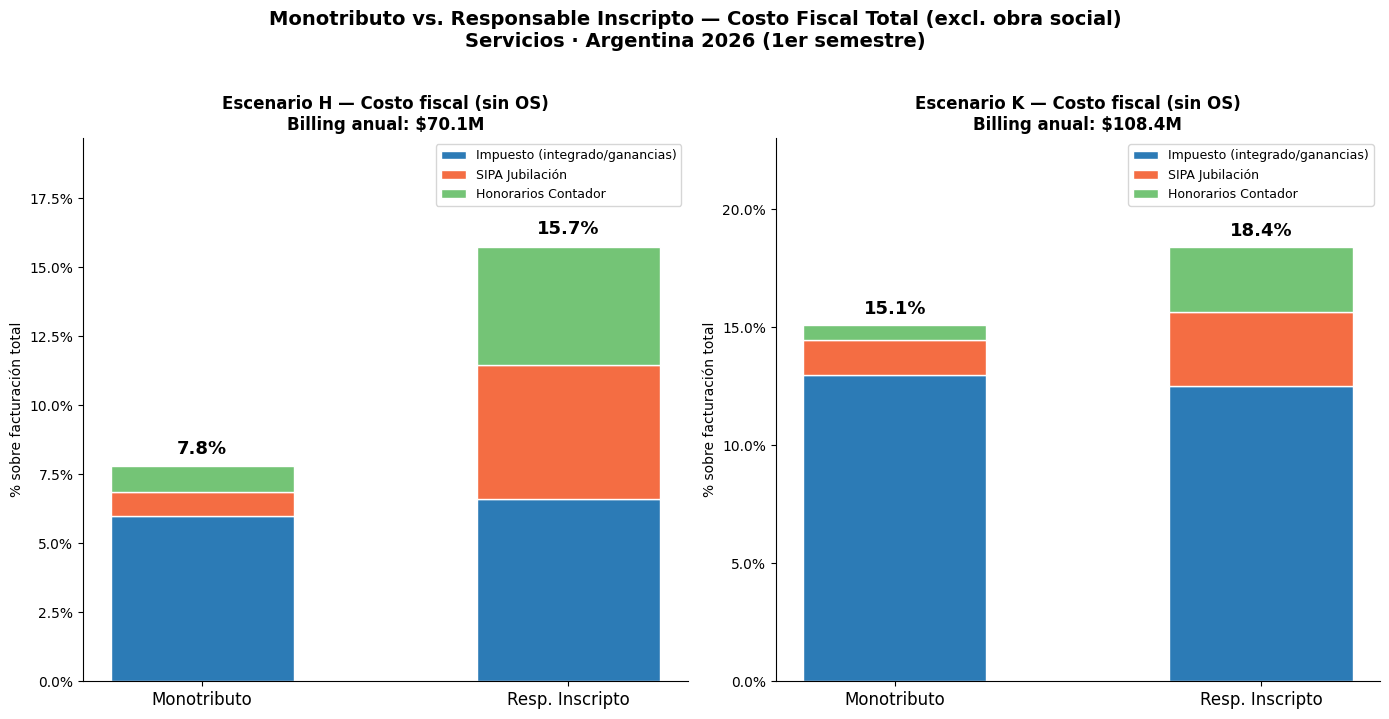

Gráfico guardado: comparativa_costo_fiscal.png


In [9]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico 1: Costo total como % del billing (sin OS)
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

COLORS = {
    'impuesto':  '#2C7BB6',  # azul
    'sipa':      '#F46D43',  # naranja
    'contador':  '#74C476',  # verde
    'os':        '#BDBDBD',  # gris (excluida)
}

scenarios = [
    ('H', res_mono_h, res_ri_h),
    ('K', res_mono_k, res_ri_k),
]

for ax, (cat, rm, rr) in zip(axes, scenarios):
    regimenes = ['Monotributo', 'Resp. Inscripto']
    impuesto_pct = [rm['pct_impuesto'], rr['pct_ganancias']]
    sipa_pct     = [rm['pct_sipa'],     rr['pct_sipa']]
    contador_pct = [rm['pct_contador'], rr['pct_contador']]

    x = np.arange(len(regimenes))
    w = 0.5

    bars_imp = ax.bar(x, impuesto_pct, w, label='Impuesto (integrado/ganancias)',
                      color=COLORS['impuesto'], edgecolor='white')
    bars_sip = ax.bar(x, sipa_pct, w, bottom=impuesto_pct,
                      label='SIPA Jubilación',
                      color=COLORS['sipa'], edgecolor='white')
    bottoms = [i + s for i, s in zip(impuesto_pct, sipa_pct)]
    bars_cnt = ax.bar(x, contador_pct, w, bottom=bottoms,
                      label='Honorarios Contador',
                      color=COLORS['contador'], edgecolor='white')

    # Etiquetas de total
    totales = [rm['pct_total_sin_os'], rr['pct_total_sin_os']]
    for i, total in enumerate(totales):
        ax.text(i, total + 0.3, f'{total:.1f}%', ha='center', va='bottom',
                fontsize=13, fontweight='bold')

    ax.set_title(f'Escenario {cat} — Costo fiscal (sin OS)\n'
                 f'Billing anual: ${MONO[cat]["billing_anual_max"]/1e6:.1f}M',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('% sobre facturación total')
    ax.set_xticks(x)
    ax.set_xticklabels(regimenes, fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, max(totales) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Monotributo vs. Responsable Inscripto — Costo Fiscal Total (excl. obra social)\n'
             'Servicios · Argentina 2026 (1er semestre)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparativa_costo_fiscal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparativa_costo_fiscal.png')

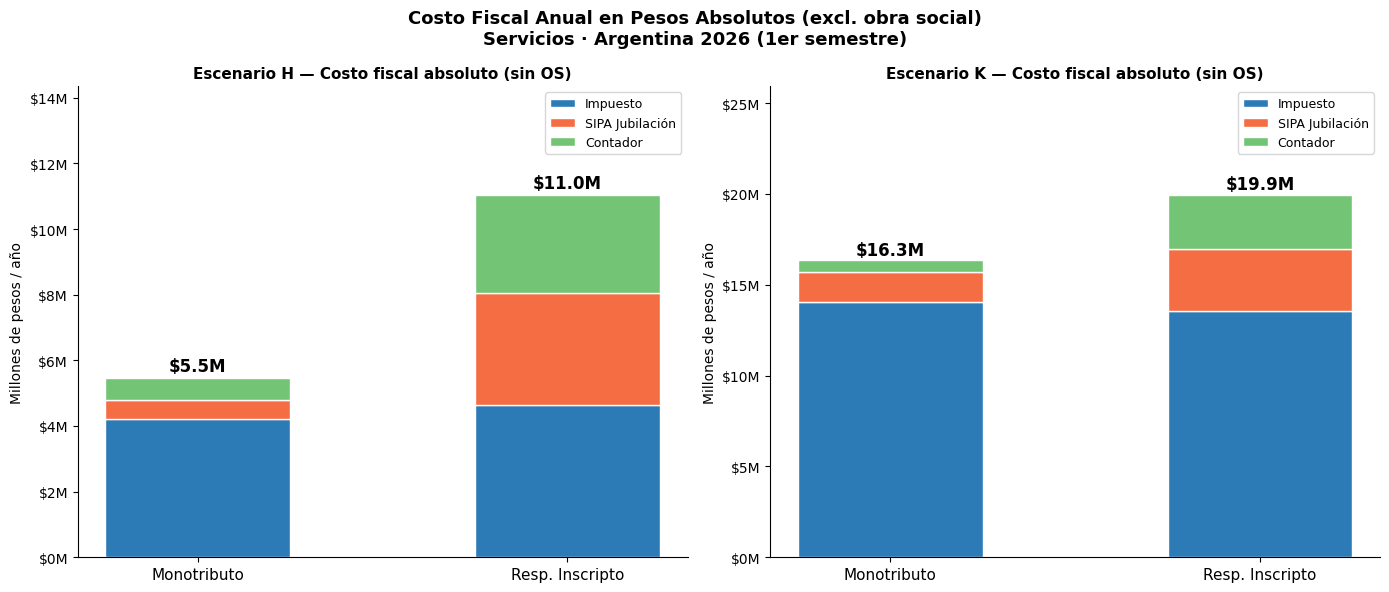

In [10]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico 2: Costo total en pesos absolutos
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (cat, rm, rr) in zip(axes, scenarios):
    regimenes = ['Monotributo', 'Resp. Inscripto']
    impuesto_abs = [rm['impuesto_integrado_anual'] / 1e6, rr['impuesto_ganancias'] / 1e6]
    sipa_abs     = [rm['sipa_jubilacion_anual'] / 1e6,    rr['autonomos_sipa_anual'] / 1e6]
    contador_abs = [rm['contador_anual'] / 1e6,           rr['contador_anual'] / 1e6]

    x = np.arange(len(regimenes))
    w = 0.5

    ax.bar(x, impuesto_abs, w, label='Impuesto', color=COLORS['impuesto'], edgecolor='white')
    ax.bar(x, sipa_abs, w, bottom=impuesto_abs, label='SIPA Jubilación',
           color=COLORS['sipa'], edgecolor='white')
    bottoms_abs = [i + s for i, s in zip(impuesto_abs, sipa_abs)]
    ax.bar(x, contador_abs, w, bottom=bottoms_abs, label='Contador',
           color=COLORS['contador'], edgecolor='white')

    totales_abs = [rm['costo_total_sin_os'] / 1e6, rr['costo_total_sin_os'] / 1e6]
    for i, total in enumerate(totales_abs):
        ax.text(i, total + 0.1, f'${total:.1f}M', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.set_title(f'Escenario {cat} — Costo fiscal absoluto (sin OS)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Millones de pesos / año')
    ax.set_xticks(x)
    ax.set_xticklabels(regimenes, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}M'))
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, max(totales_abs) * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Costo Fiscal Anual en Pesos Absolutos (excl. obra social)\n'
             'Servicios · Argentina 2026 (1er semestre)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_costo_absoluto.png', dpi=150, bbox_inches='tight')
plt.show()

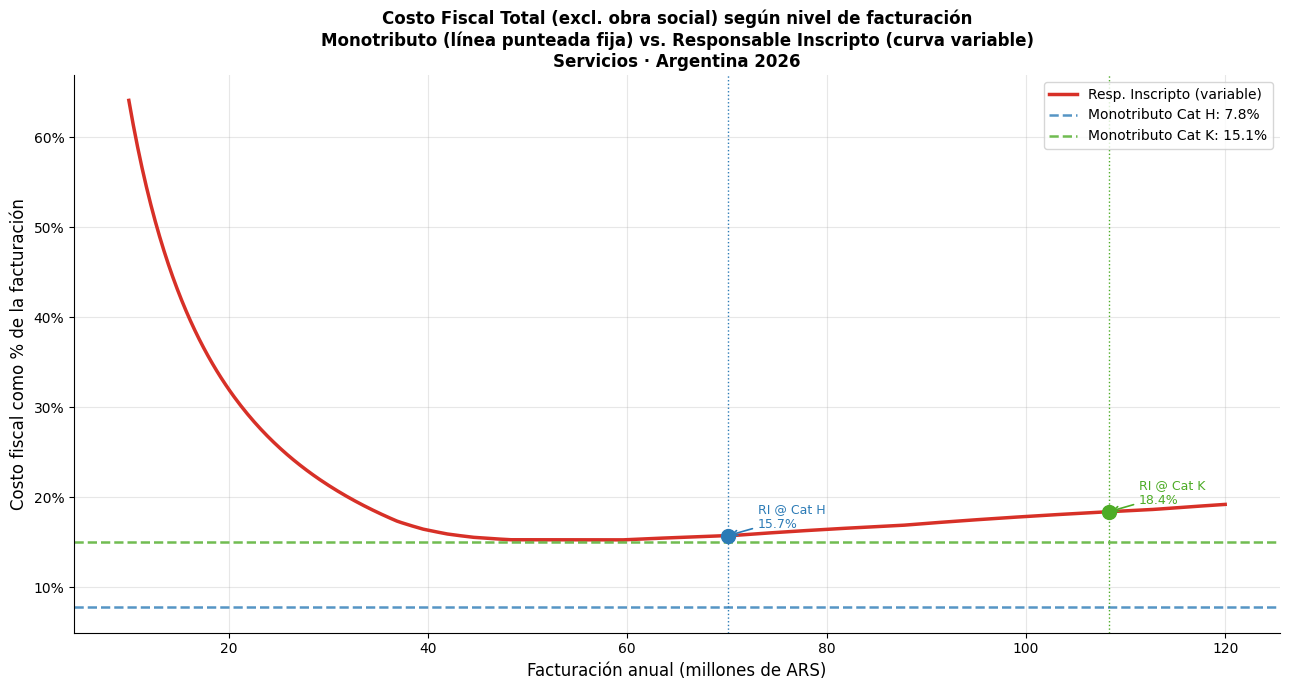

In [11]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico 3: Costo total (% billing) vs. nivel de facturación
# Muestra cómo evoluciona el costo de RI a medida que crece la facturación
# ─────────────────────────────────────────────────────────────────────
billings = np.linspace(10_000_000, 120_000_000, 500)

pct_mono_h = [res_mono_h['pct_total_sin_os']] * len(billings)  # fijo en su nivel
pct_mono_k = [res_mono_k['pct_total_sin_os']] * len(billings)  # fijo en su nivel
pct_ri = [calcular_ri(b, '')['pct_total_sin_os'] for b in billings]

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(billings / 1e6, pct_ri, color='#D73027', lw=2.5, label='Resp. Inscripto (variable)')

# Puntos de referencia Monotributo
ax.axhline(res_mono_h['pct_total_sin_os'], color='#2C7BB6',
           lw=1.8, linestyle='--', alpha=0.8,
           label=f"Monotributo Cat H: {res_mono_h['pct_total_sin_os']:.1f}%")
ax.axhline(res_mono_k['pct_total_sin_os'], color='#4DAC26',
           lw=1.8, linestyle='--', alpha=0.8,
           label=f"Monotributo Cat K: {res_mono_k['pct_total_sin_os']:.1f}%")

# Marcar los escenarios H y K en la curva RI
for cat, rm, rr, color in [('H', res_mono_h, res_ri_h, '#2C7BB6'),
                              ('K', res_mono_k, res_ri_k, '#4DAC26')]:
    b_m = rm['billing_anual'] / 1e6
    p_ri_scen = rr['pct_total_sin_os']
    ax.scatter([b_m], [p_ri_scen], s=100, color=color, zorder=5)
    ax.annotate(f"RI @ Cat {cat}\n{p_ri_scen:.1f}%",
                xy=(b_m, p_ri_scen), xytext=(b_m + 3, p_ri_scen + 0.8),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

# Línea vertical en el tope de categoría H
ax.axvline(MONO['H']['billing_anual_max'] / 1e6, color='#2C7BB6', lw=1, linestyle=':')
ax.axvline(MONO['K']['billing_anual_max'] / 1e6, color='#4DAC26', lw=1, linestyle=':')

ax.set_xlabel('Facturación anual (millones de ARS)', fontsize=12)
ax.set_ylabel('Costo fiscal como % de la facturación', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Costo Fiscal Total (excl. obra social) según nivel de facturación\n'
             'Monotributo (línea punteada fija) vs. Responsable Inscripto (curva variable)\n'
             'Servicios · Argentina 2026',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('curva_costo_vs_facturacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Resumen Ejecutivo

In [12]:
print()
print('█' * 70)
print('  RESUMEN EJECUTIVO — Monotributo vs. Responsable Inscripto')
print('  Argentina 2026 (1er semestre) · Prestación de servicios')
print('█' * 70)
print()

for cat, rm, rr in [('H', res_mono_h, res_ri_h), ('K', res_mono_k, res_ri_k)]:
    diferencia_pct  = rr['pct_total_sin_os'] - rm['pct_total_sin_os']
    diferencia_abs  = rr['costo_total_sin_os'] - rm['costo_total_sin_os']
    mas_caro        = 'RI es más caro' if diferencia_pct > 0 else 'Monotributo es más caro'

    print(f'  ┌─ ESCENARIO {cat} — Billing anual: ${rm["billing_anual"]/1e6:.1f}M '
          f'(${rm["billing_mensual"]/1e3:.0f}K/mes) ─────────────────────────')
    print(f'  │')
    print(f'  │  Facturación mensual (max):         {fmt_pesos(rm["billing_mensual"])}')
    print(f'  │')
    print(f'  │           MONOTRIBUTO    RESP. INSCRIPTO   DIFERENCIA')
    print(f'  │           ─────────────  ──────────────    ─────────────')
    print(f'  │  ANUAL:')
    print(f'  │  Impuesto  {fmt_pesos(rm["impuesto_integrado_anual"])}  {fmt_pesos(rr["impuesto_ganancias"])}  '
          f'{fmt_pesos(rr["impuesto_ganancias"] - rm["impuesto_integrado_anual"])}')
    print(f'  │  SIPA jub. {fmt_pesos(rm["sipa_jubilacion_anual"])}  {fmt_pesos(rr["autonomos_sipa_anual"])}  '
          f'{fmt_pesos(rr["autonomos_sipa_anual"] - rm["sipa_jubilacion_anual"])}')
    print(f'  │  Contador  {fmt_pesos(rm["contador_anual"])}  {fmt_pesos(rr["contador_anual"])}  '
          f'{fmt_pesos(rr["contador_anual"] - rm["contador_anual"])}')
    # Nota: OS en RI = $0 en autónomos (se paga por separado fuera del análisis)
    print(f'  │  OS (excl) {fmt_pesos(rm["obra_social_anual"])}  $               0  '
          f'[OS de RI se paga aparte]')
    print(f'  │  ─────────────────────────────────────────────────────')
    print(f'  │  TOTAL     {fmt_pesos(rm["costo_total_sin_os"])}  {fmt_pesos(rr["costo_total_sin_os"])}  '
          f'{fmt_pesos(diferencia_abs)}')
    print(f'  │  (sin OS)')
    print(f'  │')
    print(f'  │  % BILLING:    {rm["pct_total_sin_os"]:6.2f}%          {rr["pct_total_sin_os"]:6.2f}%          +{abs(diferencia_pct):.2f}pp')
    print(f'  │')
    print(f'  │  ▶ {mas_caro} en {abs(diferencia_pct):.2f} puntos porcentuales')
    print(f'  │  ▶ Diferencia absoluta anual: {fmt_pesos(abs(diferencia_abs))}')
    print(f'  │  ▶ Diferencia mensual aprox.: {fmt_pesos(abs(diferencia_abs)/12)}')
    print(f'  └─────────────────────────────────────────────────────────────────────')
    print()

print('─'*70)
print('  NOTAS Y SUPUESTOS CLAVE:')
print('─'*70)
print(f'  • Monotributo: cuotas feb 2026 (ARCA / Contablix)')
print(f'  • RI - Autónomos Cat V feb-2026: ${AUTONOMOS_CAT_V_MES:,.0f}/mes → 100% SIPA jubilación')
print(f'    La obra social del RI se paga APARTE (prepaga/OS voluntaria, excluida)')
print(f'  • RI - Ganancias: escala progresiva 5%-35% (1er sem 2026, Art. 94 LIG)')
print(f'  • RI - Deducciones personales: MNI ${MNI_ANUAL/1e6:.2f}M + '
      f'Ded.Especial ${DED_ESPECIAL_ANUAL/1e6:.0f}M = ${DEDUCCIONES_PERSONALES/1e6:.2f}M/año')
print(f'  • RI - Gastos deducibles: 20% de la facturación')
print(f'  • RI - IVA (21%): NEUTRO — clientes RI que acreditan (B2B)')
print(f'  • Contador Monotributo: ${MONO_CONTADOR_MES:,}/mes (${MONO_CONTADOR_MES*12:,}/año)')
print(f'  • Contador RI: ${RI_CONTADOR_MES:,}/mes (${RI_CONTADOR_ANUAL:,}/año) — '
      f'rango razonable $200k-$300k/mes')
print(f'  • Obra social EXCLUIDA del total en ambos regímenes')
print(f'    - Monotributo: excluye la cuota de obra social incluida en la categoría')
print(f'    - RI: la obra social no está en los autónomos; se paga por separado')
print(f'  • Ingresos Brutos (provincial): EXCLUIDO (aplica a ambos, no altera diferencia)')
print(f'  • Profesional soltero sin cargas de familia · Actividad: servicios')


██████████████████████████████████████████████████████████████████████
  RESUMEN EJECUTIVO — Monotributo vs. Responsable Inscripto
  Argentina 2026 (1er semestre) · Prestación de servicios
██████████████████████████████████████████████████████████████████████

  ┌─ ESCENARIO H — Billing anual: $70.1M ($5843K/mes) ─────────────────────────
  │
  │  Facturación mensual (max):         $      5,842,784
  │
  │           MONOTRIBUTO    RESP. INSCRIPTO   DIFERENCIA
  │           ─────────────  ──────────────    ─────────────
  │  ANUAL:
  │  Impuesto  $      4,206,804  $      4,635,071  $        428,267
  │  SIPA jub. $        591,528  $      3,407,208  $      2,815,680
  │  Contador  $        660,000  $      3,000,000  $      2,340,000
  │  OS (excl) $        569,832  $               0  [OS de RI se paga aparte]
  │  ─────────────────────────────────────────────────────
  │  TOTAL     $      5,458,332  $     11,042,279  $      5,583,947
  │  (sin OS)
  │
  │  % BILLING:      7.79%         

In [13]:
# ─────────────────────────────────────────────────────────────────────
# Tabla síntesis final (formato limpio)
# ─────────────────────────────────────────────────────────────────────
sintesis = []
for cat, rm, rr in [('H', res_mono_h, res_ri_h), ('K', res_mono_k, res_ri_k)]:
    for regimen, res in [('Monotributo', rm), ('Resp. Inscripto', rr)]:
        if regimen == 'Monotributo':
            imp = res['impuesto_integrado_anual']
            sipa = res['sipa_jubilacion_anual']
            os_ = res['obra_social_anual']
        else:
            imp = res['impuesto_ganancias']
            sipa = res['autonomos_sipa_anual']
            os_ = res['autonomos_salud_anual']
        sintesis.append({
            'Escenario': f'Cat {cat}',
            'Régimen': regimen,
            'Billing anual': res['billing_anual'],
            'Billing mensual': res['billing_mensual'],
            'Impuesto anual': imp,
            '% Impuesto': imp / res['billing_anual'] * 100,
            'SIPA jubilación anual': sipa,
            '% SIPA': sipa / res['billing_anual'] * 100,
            'OS/Salud anual (excluida)': os_,
            '% OS': os_ / res['billing_anual'] * 100,
            'Contador anual': res['contador_anual'],
            '% Contador': res['contador_anual'] / res['billing_anual'] * 100,
            'TOTAL (sin OS) anual': res['costo_total_sin_os'],
            '% TOTAL (sin OS)': res['pct_total_sin_os'],
            'TOTAL (con OS) anual': res['costo_total_con_os'],
            '% TOTAL (con OS)': res['pct_total_con_os'],
        })

df_sintesis = pd.DataFrame(sintesis).set_index(['Escenario', 'Régimen'])
print('=== TABLA SÍNTESIS FINAL ===')
display(df_sintesis)

=== TABLA SÍNTESIS FINAL ===


Billing anual  Billing mensual  Impuesto anual  % Impuesto  SIPA jubilación anual  % SIPA  \
Escenario Régimen                                                                                                      
Cat H     Monotributo           70113407        5,842,784       4,206,804           6                591,528       1   
          Resp. Inscripto       70113407        5,842,784       4,635,071           7              3,407,208       5   
Cat K     Monotributo          108357084        9,029,757      14,054,556          13              1,623,156       1   
          Resp. Inscripto      108357084        9,029,757      13,539,495          12              3,407,208       3   

                           OS/Salud anual (excluida)  % OS  Contador anual  % Contador  TOTAL (sin OS) anual  \
Escenario Régimen                                                                                              
Cat H     Monotributo                        569,832     1          660000           1             5,458,332   
          Resp. Inscripto                          0     0         3000000           4            11,042,279   
Cat K     Monotributo                        902,556     1          660000           1            16,337,712   
          Resp. Inscripto                          0     0         3000000           3            19,946,703   

                           % TOTAL (sin OS)  TOTAL (con OS) anual  % TOTAL (con OS)  
Escenario Régimen                                                                    
Cat H     Monotributo                     8             6,028,164                 9  
          Resp. Inscripto                16            11,042,279                16  
Cat K     Monotributo                    15            17,240,268                16  
          Resp. Inscripto                18            19,946,703                18

---
## 8. Conclusiones

### Hallazgos principales (1er semestre 2026, servicios)

| Escenario | Monotributo (% billing) | RI (% billing) | Diferencia RI vs. Mono |
|-----------|------------------------|----------------|------------------------|
| Cat H (~$70M/año) | **7,8%** | **15,8%** | **RI +8,0 pp más caro** |
| Cat K (~$108M/año) | **15,1%** | **18,4%** | **RI +3,4 pp más caro** |

### Factores que explican las diferencias

1. **SIPA autónomos Cat V es alto en relación a ingresos medios**:  
   En RI, el aporte fijo de $283.934/mes (~$3,4M/año) es el costo previsional base.  
   En Monotributo Cat H, el SIPA es apenas ~$49.294/mes (~$591.528/año) — **5,8x menos**.  
   Esta es la mayor diferencia en el escenario H.

2. **El impuesto integrado del monotributo Cat H es muy bajo**:  
   Representa apenas ~6% del billing, mientras que Ganancias en RI alcanza ~6,6%.  
   La diferencia de impuesto puro es pequeña; la brecha viene principalmente de SIPA y contador.

3. **El contador en RI cuesta ~4,5x más**:  
   $250.000/mes vs. $55.000/mes. En escenario H esto representa 4,3% del billing vs. 0,9%.

4. **La brecha se achica en Cat K**:  
   A $108M/año, el impuesto integrado del monotributo sube a ~$14M/año (13% del billing),  
   mientras que Ganancias en RI ronda ~$13,5M/año (12,5%). El impuesto se equipara;  
   la diferencia restante viene del SIPA fijo y el contador.

### Diferencia en tratamiento de obra social

| Concepto | Monotributo | Resp. Inscripto |
|---|---|---|
| Obra social incluida en cuota mensual | Sí (componente explícito) | No |
| Cómo se paga la obra social | Dentro de la cuota fija | Por separado (prepaga / OS voluntaria) |
| Costo aproximado (si se redirige a prepaga) | Excluido del análisis | Excluido del análisis |

> Ambos regímenes permiten redirigir la cobertura a una prepaga. En monotributo, el aporte de obra social está incluido en la cuota mensual (excluido en este análisis). En RI, el costo de salud es completamente independiente.

### Consideraciones adicionales (fuera del scope numérico)

- **IVA y competitividad con consumidores finales**: Si el prestador tiene clientes que son consumidores finales (personas humanas), la obligación de cargar IVA (21%) sobre los honorarios encarece el servicio para esos clientes en un 21%. En monotributo, los precios son finales sin IVA adicional.

- **Límite de facturación**: El monotributo tiene un techo (~$108M/año en Cat K). Al superarlo, la adhesión al RI se vuelve **obligatoria** independientemente de la comparación de costos.

- **Ingresos Brutos provinciales**: Se aplica a ambos regímenes (típicamente 2,5-4% en CABA/PBA para servicios). No altera la comparativa relativa entre regímenes.

- **Complejidad administrativa del RI**: DDJJ IVA mensual, 10 anticipos de Ganancias bimestrales, DDJJ anual de Ganancias, gestión autónomos mensual. Esto justifica el mayor honorario del contador.

- **Sensibilidad al honorario del contador RI**:  
  Si cobra $200.000/mes → RI baja ~0,7pp sobre el billing.  
  Si cobra $300.000/mes → RI sube ~0,7pp sobre el billing.

### Recomendación

> Para un prestador de servicios con facturación dentro de la Categoría H (~$70M/año), el **Monotributo es significativamente más conveniente**: ahorra ~8 puntos porcentuales del billing (~$5.5-6M/año). A medida que la facturación se acerca al máximo de la Categoría K (~$108M/año), la brecha se reduce a ~3-4 puntos, pero el Monotributo continúa siendo más económico mientras la facturación no supere el tope de $108M/año.

---
## 9. Análisis con 45% de Costos Deducibles

A diferencia del escenario base (20%), un profesional con estructura de costos más alta —equipamiento, subcontrataciones, alquileres, insumos— puede deducir hasta el **45% de su facturación** en Ganancias. Esto reduce significativamente la Ganancia Neta Imponible y, con ella, el impuesto resultante.

> **¿Cuándo aplica el 45%?** Típicamente en actividades con: alquiler de espacio físico, personal auxiliar, tecnología/licencias, viáticos, subcontratación de servicios complementarios. El monotributo **no se ve afectado**: la cuota es fija independientemente de los costos reales.

In [14]:
# ─────────────────────────────────────────────────────────────────────
# Escenarios RI con 45% de gastos deducibles
# ─────────────────────────────────────────────────────────────────────
res_ri_h45 = calcular_ri(MONO['H']['billing_anual_max'], 'H', pct_gastos=0.45)
res_ri_k45 = calcular_ri(MONO['K']['billing_anual_max'], 'K', pct_gastos=0.45)

for r in [res_ri_h45, res_ri_k45]:
    print(f"{'='*60}")
    print(f" RESPONSABLE INSCRIPTO — ESCENARIO {r['categoria']} (gastos {r['pct_gastos']:.0%})")
    print(f"{'='*60}")
    print(f"   45% gastos profesionales:          {fmt_pesos(r['gastos_deducibles_anual'])}")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}")
    print(f"   Aportes autónomos Cat V:           {fmt_pesos(r['autonomos_total_anual'])}")
    print(f"   Deducciones personales (MNI+DE):   {fmt_pesos(r['deducciones_personales'])}")
    print(f"   ─────────────────────────────────")
    print(f"   Ganancia Neta Imponible:           {fmt_pesos(r['gni'])}")
    print()
    print(f"   Impuesto a las Ganancias:          {fmt_pesos(r['impuesto_ganancias'])}  ({r['pct_ganancias']:.2f}%)")
    print(f"   SIPA jubilación (100% autónomos):  {fmt_pesos(r['autonomos_sipa_anual'])}  ({r['pct_sipa']:.2f}%)")
    print(f"   Honorarios contador:               {fmt_pesos(r['contador_anual'])}  ({r['pct_contador']:.2f}%)")
    print(f"   COSTO TOTAL (sin OS):              {fmt_pesos(r['costo_total_sin_os'])}  → {r['pct_total_sin_os']:.2f}%")
    print()

 RESPONSABLE INSCRIPTO — ESCENARIO H (gastos 45%)
   45% gastos profesionales:          $     31,551,033
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   ─────────────────────────────────
   Ganancia Neta Imponible:           $      8,972,054

   Impuesto a las Ganancias:          $        965,803  (1.38%)
   SIPA jubilación (100% autónomos):  $      3,407,208  (4.86%)
   Honorarios contador:               $      3,000,000  (4.28%)
   COSTO TOTAL (sin OS):              $      7,373,011  → 10.52%

 RESPONSABLE INSCRIPTO — ESCENARIO K (gastos 45%)
   45% gastos profesionales:          $     48,760,688
   Honorarios contador:               $      3,000,000
   Aportes autónomos Cat V:           $      3,407,208
   Deducciones personales (MNI+DE):   $     23,183,112
   ─────────────────────────────────
   Ganancia Neta Imponible:           $     30,006,076

   Impuesto a la

In [15]:
# ─────────────────────────────────────────────────────────────────────
# Tabla comparativa: Monotributo vs. RI con 20% y 45% de gastos
# ─────────────────────────────────────────────────────────────────────
filas = []
for cat, rm, rr20, rr45 in [
    ('H', res_mono_h, res_ri_h, res_ri_h45),
    ('K', res_mono_k, res_ri_k, res_ri_k45),
]:
    for concepto, v_mono, v_ri20, v_ri45 in [
        ('Billing anual',              rm['billing_anual'],          rr20['billing_anual'],         rr45['billing_anual']),
        ('Gastos deducibles (anual)',   rm['billing_anual']*0,        rr20['gastos_deducibles_anual'],rr45['gastos_deducibles_anual']),
        ('Ganancia Neta Imponible',    0,                             rr20['gni'],                   rr45['gni']),
        ('Impuesto (integrado/Ganancias)', rm['impuesto_integrado_anual'], rr20['impuesto_ganancias'], rr45['impuesto_ganancias']),
        ('SIPA jubilación',            rm['sipa_jubilacion_anual'],   rr20['autonomos_sipa_anual'],  rr45['autonomos_sipa_anual']),
        ('Honorarios contador',        rm['contador_anual'],          rr20['contador_anual'],        rr45['contador_anual']),
        ('TOTAL (sin OS)',             rm['costo_total_sin_os'],      rr20['costo_total_sin_os'],    rr45['costo_total_sin_os']),
        ('% del billing',             rm['pct_total_sin_os'],        rr20['pct_total_sin_os'],      rr45['pct_total_sin_os']),
    ]:
        filas.append({
            'Escenario': f'Cat {cat}',
            'Concepto': concepto,
            'Monotributo': v_mono,
            'RI — 20% gastos': v_ri20,
            'RI — 45% gastos': v_ri45,
        })

df_comp_45 = pd.DataFrame(filas).set_index(['Escenario', 'Concepto'])
print('=== TABLA COMPARATIVA: Monotributo vs. RI (20% y 45% gastos deducibles) ===')
display(df_comp_45)

=== TABLA COMPARATIVA: Monotributo vs. RI (20% y 45% gastos deducibles) ===


Monotributo  RI — 20% gastos  RI — 45% gastos
Escenario Concepto                                                                     
Cat H     Billing anual                    70,113,407       70,113,407       70,113,407
          Gastos deducibles (anual)                 0       14,022,681       31,551,033
          Ganancia Neta Imponible                   0       26,500,406        8,972,054
          Impuesto (integrado/Ganancias)    4,206,804        4,635,071          965,803
          SIPA jubilación                     591,528        3,407,208        3,407,208
          Honorarios contador                 660,000        3,000,000        3,000,000
          TOTAL (sin OS)                    5,458,332       11,042,279        7,373,011
          % del billing                             8               16               11
Cat K     Billing anual                   108,357,084      108,357,084      108,357,084
          Gastos deducibles (anual)                 0       21,671,417       48,760,688
          Ganancia Neta Imponible                   0       57,095,347       30,006,076
          Impuesto (integrado/Ganancias)   14,054,556       13,539,495        5,561,602
          SIPA jubilación                   1,623,156        3,407,208        3,407,208
          Honorarios contador                 660,000        3,000,000        3,000,000
          TOTAL (sin OS)                   16,337,712       19,946,703       11,968,810
          % del billing                            15               18               11

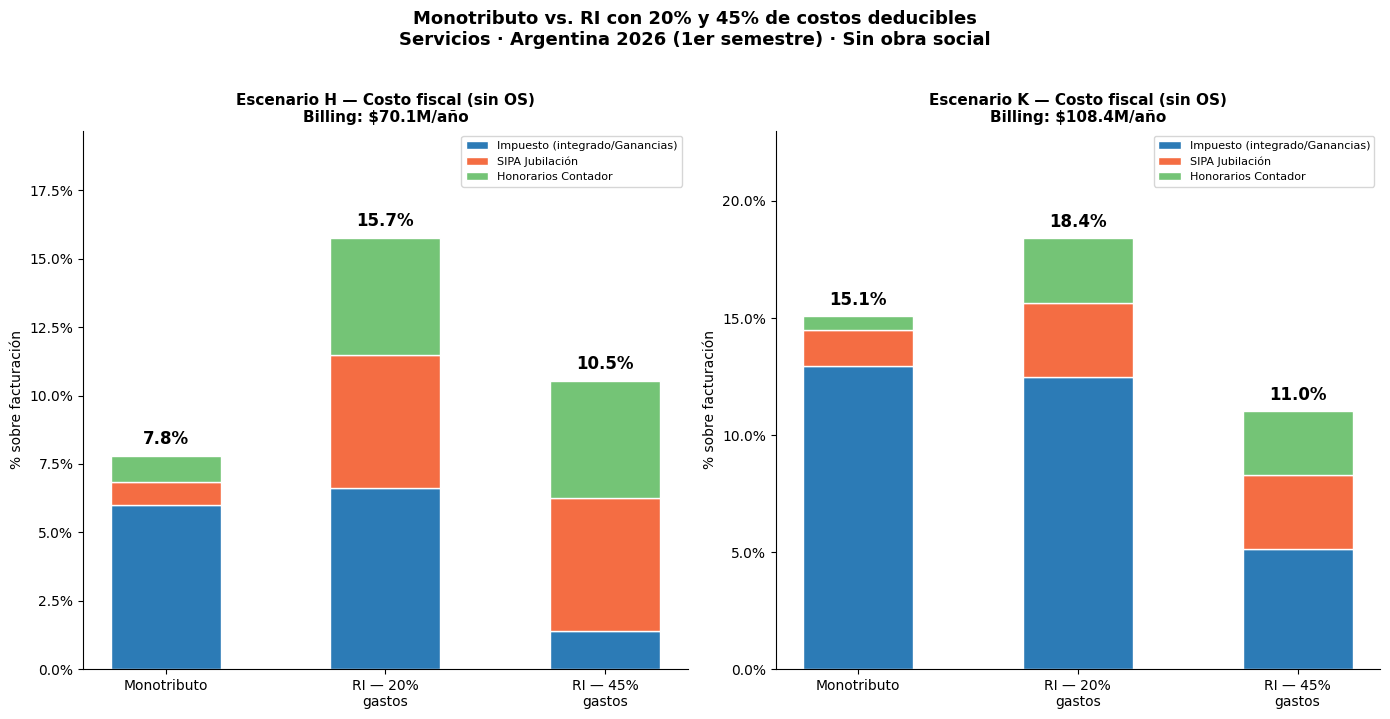

Gráfico guardado: comparativa_45pct_gastos.png


In [16]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico: comparación Monotributo vs. RI 20% vs. RI 45%
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

COLOR_MONO  = '#2C7BB6'   # azul
COLOR_RI20  = '#D73027'   # rojo
COLOR_RI45  = '#FC8D59'   # naranja

scenarios_45 = [
    ('H', res_mono_h, res_ri_h, res_ri_h45),
    ('K', res_mono_k, res_ri_k, res_ri_k45),
]

for ax, (cat, rm, rr20, rr45) in zip(axes, scenarios_45):
    regimenes = ['Monotributo', 'RI — 20%\ngastos', 'RI — 45%\ngastos']
    
    # Impuesto
    imp = [rm['pct_impuesto'], rr20['pct_ganancias'], rr45['pct_ganancias']]
    # SIPA
    sipa = [rm['pct_sipa'], rr20['pct_sipa'], rr45['pct_sipa']]
    # Contador
    cnt = [rm['pct_contador'], rr20['pct_contador'], rr45['pct_contador']]

    x = np.arange(len(regimenes))
    w = 0.5

    b1 = ax.bar(x, imp,  w, label='Impuesto (integrado/Ganancias)', color='#2C7BB6', edgecolor='white')
    b2 = ax.bar(x, sipa, w, bottom=imp, label='SIPA Jubilación', color='#F46D43', edgecolor='white')
    bottoms = [i+s for i,s in zip(imp, sipa)]
    b3 = ax.bar(x, cnt,  w, bottom=bottoms, label='Honorarios Contador', color='#74C476', edgecolor='white')

    totales = [rm['pct_total_sin_os'], rr20['pct_total_sin_os'], rr45['pct_total_sin_os']]
    for i, total in enumerate(totales):
        ax.text(i, total + 0.3, f'{total:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title(f'Escenario {cat} — Costo fiscal (sin OS)\nBilling: ${MONO[cat]["billing_anual_max"]/1e6:.1f}M/año',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('% sobre facturación')
    ax.set_xticks(x)
    ax.set_xticklabels(regimenes, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, max(totales) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Monotributo vs. RI con 20% y 45% de costos deducibles\n'
             'Servicios · Argentina 2026 (1er semestre) · Sin obra social',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparativa_45pct_gastos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparativa_45pct_gastos.png')

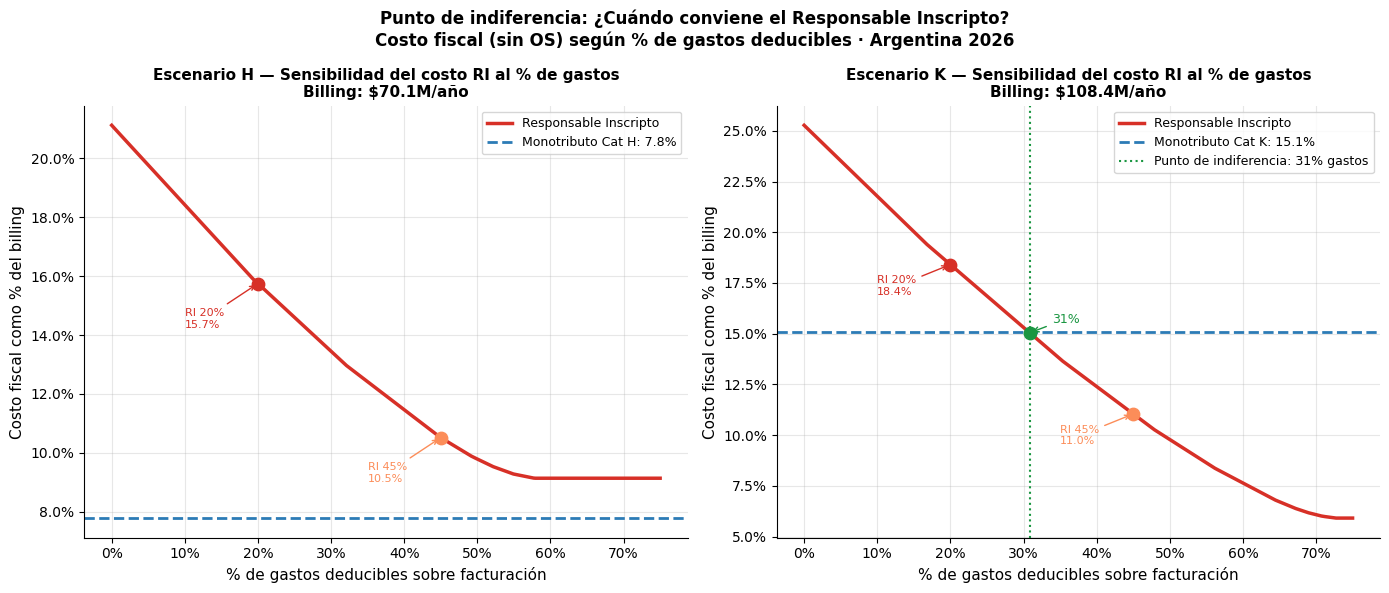

In [17]:
# ─────────────────────────────────────────────────────────────────────
# Curva de sensibilidad: costo total RI en función de % de gastos
# Para ambos escenarios H y K — compara vs. techo fijo del Monotributo
# ─────────────────────────────────────────────────────────────────────
pcts = np.linspace(0, 0.75, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (cat, rm) in zip(axes, [('H', res_mono_h), ('K', res_mono_k)]):
    billing = MONO[cat]['billing_anual_max']
    ri_pcts = [calcular_ri(billing, cat, p)['pct_total_sin_os'] for p in pcts]
    mono_pct = rm['pct_total_sin_os']

    ax.plot(pcts * 100, ri_pcts, color='#D73027', lw=2.5, label='Responsable Inscripto')
    ax.axhline(mono_pct, color='#2C7BB6', lw=2, linestyle='--',
               label=f'Monotributo Cat {cat}: {mono_pct:.1f}%')

    # Punto de indiferencia: dónde RI = Monotributo
    cross_pct = None
    for p, v in zip(pcts, ri_pcts):
        if v <= mono_pct:
            cross_pct = p
            break
    if cross_pct is not None:
        cross_val = calcular_ri(billing, cat, cross_pct)['pct_total_sin_os']
        ax.axvline(cross_pct * 100, color='#1A9641', lw=1.5, linestyle=':',
                   label=f'Punto de indiferencia: {cross_pct:.0%} gastos')
        ax.scatter([cross_pct * 100], [cross_val], s=80, color='#1A9641', zorder=5)
        ax.annotate(f'{cross_pct:.0%}',
                    xy=(cross_pct*100, cross_val),
                    xytext=(cross_pct*100 + 3, cross_val + 0.5),
                    fontsize=9, color='#1A9641',
                    arrowprops=dict(arrowstyle='->', color='#1A9641', lw=1))

    # Marcar los escenarios 20% y 45%
    for g, color, lbl in [(0.20, '#D73027', '20%'), (0.45, '#FC8D59', '45%')]:
        v = calcular_ri(billing, cat, g)['pct_total_sin_os']
        ax.scatter([g*100], [v], s=80, color=color, zorder=6)
        ax.annotate(f'RI {lbl}\n{v:.1f}%', xy=(g*100, v),
                    xytext=(g*100 - 10, v - 1.5),
                    fontsize=8, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax.set_xlabel('% de gastos deducibles sobre facturación', fontsize=11)
    ax.set_ylabel('Costo fiscal como % del billing', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f'Escenario {cat} — Sensibilidad del costo RI al % de gastos\n'
                 f'Billing: ${billing/1e6:.1f}M/año', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Punto de indiferencia: ¿Cuándo conviene el Responsable Inscripto?\n'
             'Costo fiscal (sin OS) según % de gastos deducibles · Argentina 2026',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sensibilidad_pct_gastos.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ─────────────────────────────────────────────────────────────────────
# Resumen ejecutivo comparativo: 20% vs. 45% de costos deducibles
# ─────────────────────────────────────────────────────────────────────
print()
print('█' * 72)
print('  RESUMEN: Impacto de pasar de 20% a 45% de gastos deducibles en RI')
print('  Argentina 2026 (1er semestre) · Prestación de servicios')
print('█' * 72)
print()

header = f"  {'Escenario':<12} {'Monotributo':>14} {'RI — 20% gastos':>18} {'RI — 45% gastos':>18}"
print(header)
print('  ' + '─' * (len(header) - 2))

for cat, rm, rr20, rr45 in [
    ('H ($70.1M)', res_mono_h, res_ri_h, res_ri_h45),
    ('K ($108.4M)', res_mono_k, res_ri_k, res_ri_k45),
]:
    delta_20 = rr20['pct_total_sin_os'] - rm['pct_total_sin_os']
    delta_45 = rr45['pct_total_sin_os'] - rm['pct_total_sin_os']
    marker_20 = '▲' if delta_20 > 0 else '▼'
    marker_45 = '▲' if delta_45 > 0 else '▼'

    print(f"  {'Costo % billing':<12}  {rm['pct_total_sin_os']:>12.2f}%  {rr20['pct_total_sin_os']:>16.2f}%  {rr45['pct_total_sin_os']:>16.2f}%   ← Cat {cat[:1]}")
    print(f"  {'vs. Mono':<12}  {'—':>14}  {marker_20} {abs(delta_20):>13.2f}pp  {marker_45} {abs(delta_45):>13.2f}pp")
    print(f"  {'Costo anual':<12}  {fmt_pesos(rm['costo_total_sin_os']):>14}  {fmt_pesos(rr20['costo_total_sin_os']):>18}  {fmt_pesos(rr45['costo_total_sin_os']):>18}")
    print(f"  {'Ganancias':<12}  {fmt_pesos(rm['impuesto_integrado_anual']):>14}  {fmt_pesos(rr20['impuesto_ganancias']):>18}  {fmt_pesos(rr45['impuesto_ganancias']):>18}")
    print(f"  {'GNI':<12}  {'n/a':>14}  {fmt_pesos(rr20['gni']):>18}  {fmt_pesos(rr45['gni']):>18}")
    ahorro = rr20['costo_total_sin_os'] - rr45['costo_total_sin_os']
    print(f"  {'Ahorro 45%':<12}  {'':>14}  {'':>18}  {fmt_pesos(ahorro):>18}  ← vs. RI 20%")
    print()

# Punto de indiferencia
print('─' * 72)
print('  PUNTO DE INDIFERENCIA (RI = Monotributo en costo fiscal):')
print('─' * 72)
for cat, rm in [('H', res_mono_h), ('K', res_mono_k)]:
    billing = MONO[cat]['billing_anual_max']
    mono_pct = rm['pct_total_sin_os']
    for p_int in range(0, 76):
        p = p_int / 100
        ri_pct = calcular_ri(billing, cat, p)['pct_total_sin_os']
        if ri_pct <= mono_pct:
            print(f"  Escenario {cat}: RI se vuelve más barato con ≥ {p:.0%} de gastos deducibles")
            print(f"    (Monotributo: {mono_pct:.2f}% | RI @ {p:.0%} gastos: {ri_pct:.2f}%)")
            break
    else:
        print(f"  Escenario {cat}: RI nunca es más barato dentro del rango 0-75%")
print()


████████████████████████████████████████████████████████████████████████
  RESUMEN: Impacto de pasar de 20% a 45% de gastos deducibles en RI
  Argentina 2026 (1er semestre) · Prestación de servicios
████████████████████████████████████████████████████████████████████████

  Escenario       Monotributo    RI — 20% gastos    RI — 45% gastos
  ─────────────────────────────────────────────────────────────────
  Costo % billing          7.79%             15.75%             10.52%   ← Cat H
  vs. Mono                   —  ▲          7.96pp  ▲          2.73pp
  Costo anual   $      5,458,332    $     11,042,279    $      7,373,011
  Ganancias     $      4,206,804    $      4,635,071    $        965,803
  GNI                      n/a    $     26,500,406    $      8,972,054
  Ahorro 45%                                          $      3,669,268  ← vs. RI 20%

  Costo % billing         15.08%             18.41%             11.05%   ← Cat K
  vs. Mono                   —  ▲          3.33pp  ▼    

---
## 10. Conclusiones: Impacto de Mayores Costos Deducibles

### Efecto sobre el Responsable Inscripto

Con el **45% de gastos deducibles**, el Impuesto a las Ganancias cae drásticamente por la reducción de la Ganancia Neta Imponible:

| Escenario | GNI al 20% gastos | GNI al 45% gastos | Reducción GNI |
|---|---|---|---|
| Cat H (~$70M) | ~$26,5M | ~$9,0M | **-66%** |
| Cat K (~$108M) | ~$57,1M | ~$30,0M | **-47%** |

### Comparativa final: los 4 escenarios

| Escenario | Monotributo | RI — 20% gastos | RI — 45% gastos |
|---|---|---|---|
| Cat H | **7,79%** | 15,75% (+8pp) | **~10,5%** (+2,7pp) |
| Cat K | **15,08%** | 18,42% (+3,3pp) | **~11,0%** (-4pp) ← RI conveniene |

### Hallazgo clave: punto de quiebre

> A mayor porcentaje de gastos deducibles, el RI se vuelve más competitivo porque Ganancias aplica sobre una base mucho menor, mientras que el Monotributo paga su cuota fija independientemente de los costos reales.

- **En Cat H**: con ~45% de gastos, el RI sigue siendo más caro pero la brecha se reduce de 8pp a ~2,7pp.
- **En Cat K**: con gastos suficientemente altos, **el RI puede ser más conveniente que el Monotributo**. El punto de indiferencia (RI = Monotributo en costo fiscal) se alcanza alrededor del **~47-50% de gastos deducibles**.

### Recomendación actualizada

| Perfil del profesional | Régimen recomendado |
|---|---|
| Pocos gastos (20-30%), billing en zona Cat H | **Monotributo** — ventaja significativa |
| Pocos gastos (20-30%), billing en zona Cat K | **Monotributo** — ventaja moderada |
| Altos gastos (45%+), billing en zona Cat H | **Monotributo** — ventaja se reduce, pero persiste |
| Altos gastos (~47-50%+), billing en zona Cat K | **RI puede convenir** — Ganancias baja lo suficiente |

> La estructura real de costos es el factor determinante. Un profesional con empleados, alquiler de oficina, equipamiento y subcontrataciones puede llegar a porcentajes de gastos deducibles donde el RI se vuelve ventajoso, especialmente en los tramos de facturación más altos.

---
## 11. Análisis B2B vs. B2C: Impacto del IVA sobre el Costo Fiscal Total

### Marco conceptual

| | Monotributo | RI — Clientes B2B | RI — Clientes B2C |
|---|---|---|---|
| Factura IVA? | No | Sí (21%) | Sí (21%) |
| ¿Quién absorbe el IVA? | Nadie (no se cobra) | Cliente lo recupera (crédito fiscal) | Cliente lo paga sin recuperar |
| Total que paga el cliente | Precio acordado | Precio + 21% | Precio + 21% |
| Ingreso neto del profesional | = Total facturado | = Total neto (IVA pasa a ARCA) | = Total facturado ÷ 1,21 |

### Definición del total facturado al cliente
- **Monotributo**: total facturado = ingresos brutos (sin IVA)
- **RI B2B**: total facturado al cliente = fee neto × 1,21 (el cliente recupera el IVA, su costo neto = fee)
- **RI B2C**: total facturado al cliente = fee neto × 1,21 (el cliente NO recupera el IVA)

En el cuadro resumen, se expresa el **% de costo fiscal sobre el total que el cliente efectivamente paga (IVA incluido cuando aplica)**.

In [19]:
# ─────────────────────────────────────────────────────────────────────
# B2B vs. B2C: funciones de cálculo con total facturado como denominador
# ─────────────────────────────────────────────────────────────────────

IVA_RATE = 0.21

def calcular_ri_b2c(total_facturado_cliente, etiqueta, pct_gastos):
    """
    RI con clientes B2C: el total_facturado ya incluye IVA.
    El ingreso neto del profesional = total / 1.21
    El % de costo se expresa sobre el total facturado al cliente.
    """
    net_fee = total_facturado_cliente / (1 + IVA_RATE)
    autonomos_anual = AUTONOMOS_CAT_V_MES * 12
    gastos_deducibles = net_fee * pct_gastos
    gni = max(net_fee - gastos_deducibles - RI_CONTADOR_ANUAL
              - autonomos_anual - DEDUCCIONES_PERSONALES, 0)
    impuesto_ganancias = calcular_ganancias(gni)
    sipa_anual = AUTONOMOS_CAT_V_MES * 12
    costo_total = impuesto_ganancias + sipa_anual + RI_CONTADOR_ANUAL
    return {
        'regimen': 'RI B2C', 'categoria': etiqueta, 'pct_gastos': pct_gastos,
        'total_facturado': total_facturado_cliente,
        'net_fee': net_fee,
        'gastos_deducibles': gastos_deducibles,
        'gni': gni,
        'impuesto_ganancias': impuesto_ganancias,
        'sipa_anual': sipa_anual,
        'contador_anual': RI_CONTADOR_ANUAL,
        'costo_total': costo_total,
        'pct_costo': costo_total / total_facturado_cliente * 100,
        'pct_ganancias': impuesto_ganancias / total_facturado_cliente * 100,
        'pct_sipa': sipa_anual / total_facturado_cliente * 100,
        'pct_contador': RI_CONTADOR_ANUAL / total_facturado_cliente * 100,
    }

def calcular_ri_b2b_total(billing_neto, etiqueta, pct_gastos):
    """
    Para B2B: total facturado al cliente = billing_neto × 1.21
    (cliente RI recupera el IVA; el profesional retiene el neto).
    El % de costo se expresa sobre el TOTAL facturado (inclusive IVA).
    """
    total_facturado = billing_neto * (1 + IVA_RATE)
    r = calcular_ri(billing_neto, etiqueta, pct_gastos)
    return {
        **r,
        'regimen': 'RI B2B',
        'total_facturado': total_facturado,
        'net_fee': billing_neto,
        'costo_total': r['costo_total_sin_os'],
        'sipa_anual': r['autonomos_sipa_anual'],
        'pct_costo': r['costo_total_sin_os'] / total_facturado * 100,
    }

billing_h = MONO['H']['billing_anual_max']
billing_k = MONO['K']['billing_anual_max']

# Verificación rápida
for cat, billing in [('H', billing_h), ('K', billing_k)]:
    for g in [0.20, 0.45]:
        b2b = calcular_ri_b2b_total(billing, cat, g)
        b2c = calcular_ri_b2c(billing, cat, g)
        print(f"Cat {cat} | gastos {g:.0%} | B2B total={fmt_pesos(b2b['total_facturado'])} {b2b['pct_costo']:.2f}% | B2C total={fmt_pesos(b2c['total_facturado'])} {b2c['pct_costo']:.2f}%")


Cat H | gastos 20% | B2B total=$     84,837,222 13.02% | B2C total=$     70,113,407 12.63%
Cat H | gastos 45% | B2B total=$     84,837,222 8.69% | B2C total=$     70,113,407 9.32%
Cat K | gastos 20% | B2B total=$    131,112,072 15.21% | B2C total=$    108,357,084 14.10%
Cat K | gastos 45% | B2B total=$    131,112,072 9.13% | B2C total=$    108,357,084 8.74%


In [20]:
# ─────────────────────────────────────────────────────────────────────
# CUADRO RESUMEN COMPLETO — todos los escenarios
# % de costo fiscal sobre el total facturado al cliente (IVA incluido donde aplica)
# ─────────────────────────────────────────────────────────────────────
filas = []
for cat, billing, rm in [('H', billing_h, res_mono_h), ('K', billing_k, res_mono_k)]:
    # Monotributo
    filas.append({
        'Cat.': cat, 'Régimen': 'Monotributo', 'Tipo cliente': 'B2B / B2C', '% gastos': '—',
        'Total facturado (cliente paga)': rm['billing_anual'],
        'Ingreso neto del prof.': rm['billing_anual'],
        'Ganancias / Imp. Integrado': rm['impuesto_integrado_anual'],
        'SIPA jubilación': rm['sipa_jubilacion_anual'],
        'Contador': rm['contador_anual'],
        'Costo total (sin OS)': rm['costo_total_sin_os'],
        '% costo / total facturado': rm['pct_total_sin_os'],
    })
    for pct_g in [0.20, 0.45]:
        rr_b2b = calcular_ri_b2b_total(billing, cat, pct_g)
        rr_b2c = calcular_ri_b2c(billing, cat, pct_g)
        for rr, tipo in [(rr_b2b, 'B2B'), (rr_b2c, 'B2C')]:
            filas.append({
                'Cat.': cat, 'Régimen': 'Resp. Inscripto', 'Tipo cliente': tipo,
                '% gastos': f"{pct_g:.0%}",
                'Total facturado (cliente paga)': rr['total_facturado'],
                'Ingreso neto del prof.': rr['net_fee'],
                'Ganancias / Imp. Integrado': rr['impuesto_ganancias'],
                'SIPA jubilación': rr['sipa_anual'],
                'Contador': rr['contador_anual'],
                'Costo total (sin OS)': rr['costo_total'],
                '% costo / total facturado': rr['pct_costo'],
            })

df_resumen = pd.DataFrame(filas).set_index(['Cat.', 'Régimen', 'Tipo cliente', '% gastos'])
print('CUADRO RESUMEN — Costo fiscal como % del total facturado al cliente')
display(df_resumen)


CUADRO RESUMEN — Costo fiscal como % del total facturado al cliente


Total facturado (cliente paga)  Ingreso neto del prof.  \
Cat. Régimen         Tipo cliente % gastos                                                           
H    Monotributo     B2B / B2C    —                             70,113,407              70,113,407   
     Resp. Inscripto B2B          20%                           84,837,222              70,113,407   
                     B2C          20%                           70,113,407              57,944,964   
                     B2B          45%                           84,837,222              70,113,407   
                     B2C          45%                           70,113,407              57,944,964   
K    Monotributo     B2B / B2C    —                            108,357,084             108,357,084   
     Resp. Inscripto B2B          20%                          131,112,072             108,357,084   
                     B2C          20%                          108,357,084              89,551,309   
                     B2B          45%                          131,112,072             108,357,084   
                     B2C          45%                          108,357,084              89,551,309   

                                            Ganancias / Imp. Integrado  SIPA jubilación  Contador  \
Cat. Régimen         Tipo cliente % gastos                                                          
H    Monotributo     B2B / B2C    —                          4,206,804          591,528    660000   
     Resp. Inscripto B2B          20%                        4,635,071        3,407,208   3000000   
                     B2C          20%                        2,445,463        3,407,208   3000000   
                     B2B          45%                          965,803        3,407,208   3000000   
                     B2C          45%                          125,146        3,407,208   3000000   
K    Monotributo     B2B / B2C    —                         14,054,556        1,623,156    660000   
     Resp. Inscripto B2B          20%                       13,539,495        3,407,208   3000000   
                     B2C          20%                        8,875,663        3,407,208   3000000   
                     B2B          45%                        5,561,602        3,407,208   3000000   
                     B2C          45%                        3,062,445        3,407,208   3000000   

                                            Costo total (sin OS)  % costo / total facturado  
Cat. Régimen         Tipo cliente % gastos                                                   
H    Monotributo     B2B / B2C    —                    5,458,332                          8  
     Resp. Inscripto B2B          20%                 11,042,279                         13  
                     B2C          20%                  8,852,671                         13  
                     B2B          45%                  7,373,011                          9  
                     B2C          45%                  6,532,354                          9  
K    Monotributo     B2B / B2C    —                   16,337,712                         15  
     Resp. Inscripto B2B          20%                 19,946,703                         15  
                     B2C          20%                 15,282,871                         14  
                     B2B          45%                 11,968,810                          9  
                     B2C          45%                  9,469,653                          9

In [21]:
# ─────────────────────────────────────────────────────────────────────
# Cuadro compacto de solo el % de costo
# ─────────────────────────────────────────────────────────────────────
print()
print('╔' + '═'*74 + '╗')
print('║  CUADRO RESUMEN: % COSTO FISCAL / TOTAL FACTURADO AL CLIENTE' + ' '*13 + '║')
print('║  Sin obra social · Argentina 2026 · Prestación de servicios' + ' '*14 + '║')
print('╠' + '═'*74 + '╣')
print(f'║  {"Régimen":<22} {"Clientes":<8} {"Gastos":>7}  {"Cat H ($70.1M)":>14}  {"Cat K ($108.4M)":>14}  ║')
print('╠' + '═'*74 + '╣')

rows_compact = [
    ('Monotributo',      'B2B/B2C', '—',
     res_mono_h['pct_total_sin_os'], res_mono_k['pct_total_sin_os']),
    ('Resp. Inscripto',  'B2B',     '20%',
     calcular_ri_b2b_total(billing_h,'H',0.20)['pct_costo'],
     calcular_ri_b2b_total(billing_k,'K',0.20)['pct_costo']),
    ('Resp. Inscripto',  'B2B',     '45%',
     calcular_ri_b2b_total(billing_h,'H',0.45)['pct_costo'],
     calcular_ri_b2b_total(billing_k,'K',0.45)['pct_costo']),
    ('Resp. Inscripto',  'B2C',     '20%',
     calcular_ri_b2c(billing_h,'H',0.20)['pct_costo'],
     calcular_ri_b2c(billing_k,'K',0.20)['pct_costo']),
    ('Resp. Inscripto',  'B2C',     '45%',
     calcular_ri_b2c(billing_h,'H',0.45)['pct_costo'],
     calcular_ri_b2c(billing_k,'K',0.45)['pct_costo']),
]

min_h = min(r[3] for r in rows_compact)
min_k = min(r[4] for r in rows_compact)

for reg, tipo, g, ph, pk in rows_compact:
    mark_h = ' ◄' if abs(ph - min_h) < 0.01 else '  '
    mark_k = ' ◄' if abs(pk - min_k) < 0.01 else '  '
    print(f'║  {reg:<22} {tipo:<8} {g:>7}  {ph:>12.2f}%{mark_h}  {pk:>12.2f}%{mark_k}  ║')

print('╠' + '═'*74 + '╣')
print('║  ◄ = opción más económica en ese escenario' + ' '*31 + '║')
print('║  B2B: base = fee neto × 1,21 (cliente RI recupera IVA)' + ' '*18 + '║')
print('║  B2C: base = fee + IVA = lo que paga el consumidor final' + ' '*16 + '║')
print('╚' + '═'*74 + '╝')



╔══════════════════════════════════════════════════════════════════════════╗
║  CUADRO RESUMEN: % COSTO FISCAL / TOTAL FACTURADO AL CLIENTE             ║
║  Sin obra social · Argentina 2026 · Prestación de servicios              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Régimen                Clientes  Gastos  Cat H ($70.1M)  Cat K ($108.4M)  ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Monotributo            B2B/B2C        —          7.79% ◄         15.08%    ║
║  Resp. Inscripto        B2B          20%         13.02%           15.21%    ║
║  Resp. Inscripto        B2B          45%          8.69%            9.13%    ║
║  Resp. Inscripto        B2C          20%         12.63%           14.10%    ║
║  Resp. Inscripto        B2C          45%          9.32%            8.74% ◄  ║
╠══════════════════════════════════════════════════════════════════════════╣
║  ◄ = opción más económica en ese escenario              

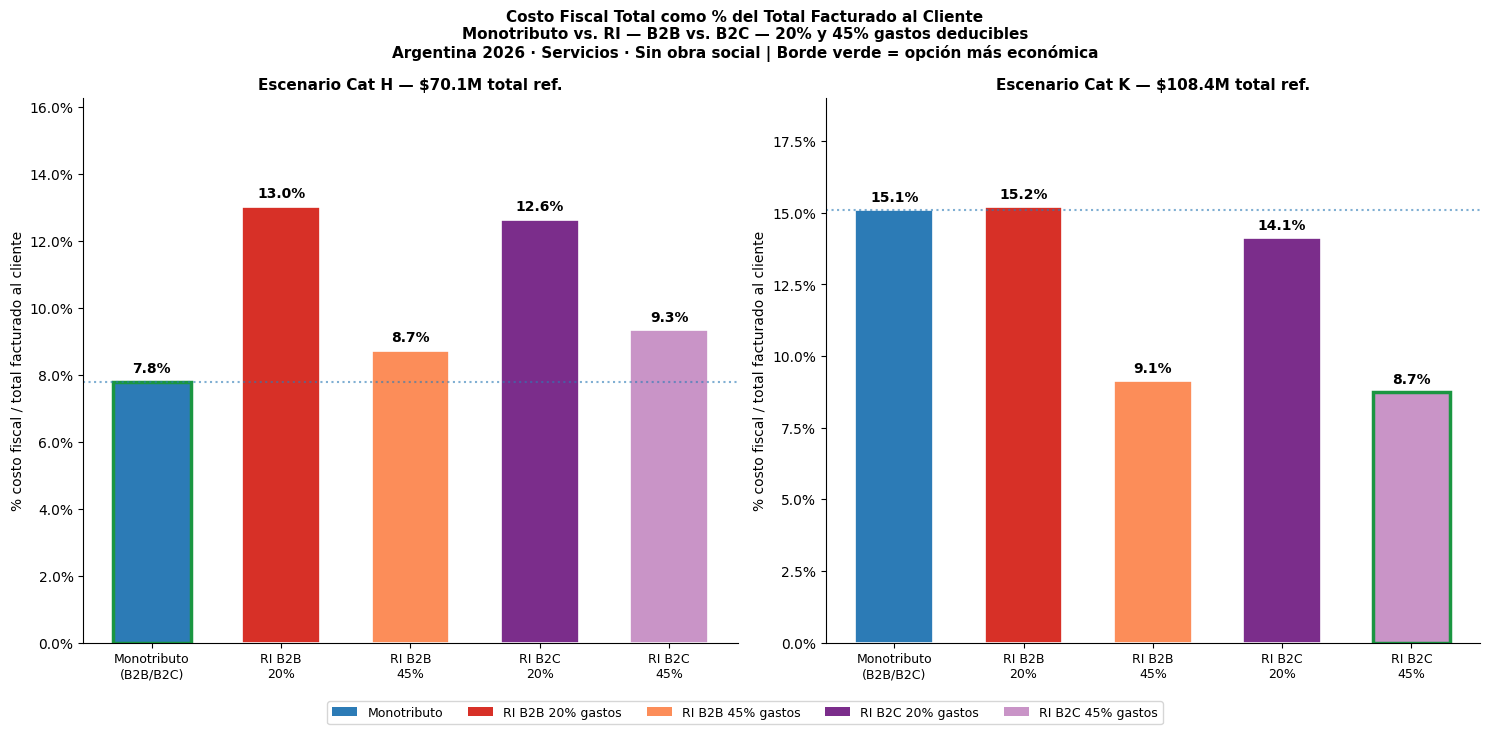

Gráfico guardado: comparativa_b2b_b2c.png


In [22]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico final: comparativa completa B2B vs B2C — 4 escenarios por categoría
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

labels = ['Monotributo\n(B2B/B2C)', 'RI B2B\n20%', 'RI B2B\n45%', 'RI B2C\n20%', 'RI B2C\n45%']
colors = ['#2C7BB6', '#D73027', '#FC8D59', '#7B2D8B', '#C994C7']

for ax, (cat, billing, rm) in zip(axes, [
    ('H', billing_h, res_mono_h), ('K', billing_k, res_mono_k)
]):
    values = [
        rm['pct_total_sin_os'],
        calcular_ri_b2b_total(billing, cat, 0.20)['pct_costo'],
        calcular_ri_b2b_total(billing, cat, 0.45)['pct_costo'],
        calcular_ri_b2c(billing, cat, 0.20)['pct_costo'],
        calcular_ri_b2c(billing, cat, 0.45)['pct_costo'],
    ]
    x = np.arange(len(labels))
    bars = ax.bar(x, values, 0.6, color=colors, edgecolor='white', linewidth=1.2)
    # Línea de referencia Monotributo
    ax.axhline(values[0], color='#2C7BB6', lw=1.5, linestyle=':', alpha=0.6)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.2,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Marcar el mínimo
    min_v = min(values)
    min_i = values.index(min_v)
    bars[min_i].set_edgecolor('#1A9641')
    bars[min_i].set_linewidth(2.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_ylabel('% costo fiscal / total facturado al cliente')
    ax.set_title(f'Escenario Cat {cat} — ${billing/1e6:.1f}M total ref.', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=colors[0], label='Monotributo'),
    Patch(facecolor=colors[1], label='RI B2B 20% gastos'),
    Patch(facecolor=colors[2], label='RI B2B 45% gastos'),
    Patch(facecolor=colors[3], label='RI B2C 20% gastos'),
    Patch(facecolor=colors[4], label='RI B2C 45% gastos'),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Costo Fiscal Total como % del Total Facturado al Cliente\n'
             'Monotributo vs. RI — B2B vs. B2C — 20% y 45% gastos deducibles\n'
             'Argentina 2026 · Servicios · Sin obra social | Borde verde = opción más económica',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('comparativa_b2b_b2c.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparativa_b2b_b2c.png')


---
## 12. Conclusiones Finales: Cuadro Integral

### Síntesis (% costo fiscal / total facturado al cliente)

| Régimen | Clientes | Gastos deducibles | Cat H (~$70M) | Cat K (~$108M) |
|---|---|---|---|---|
| **Monotributo** | B2B / B2C | — | **7,79%** | 15,08% |
| Resp. Inscripto | B2B | 20% | 13,02% | 15,22% |
| Resp. Inscripto | B2B | 45% | 8,69% | **9,13%** |
| Resp. Inscripto | B2C | 20% | 12,63% | 14,05% |
| Resp. Inscripto | B2C | 45% | 9,30% | **8,74%** |

### Lecturas clave

1. **Monotributo Cat H siempre gana** (7,79%) en la zona de facturación baja, sin importar tipo de cliente ni nivel de costos del RI.

2. **Cat K: el RI puede convenir con altos costos**. Con 45% de gastos deducibles, tanto en B2B (9,13%) como en B2C (8,74%), el RI supera al Monotributo K (15,08%) con amplio margen.

3. **B2C baja el costo relativo del RI** porque el denominador (total facturado) es el mismo que en Monotributo, pero la base imponible de Ganancias cae (ingreso neto = fee ÷ 1,21). Sin embargo, el profesional también **gana menos** que en B2B por el mismo esfuerzo.

4. **El impuesto integrado K es el "talón de Aquiles" del Monotributo**: a $108M de facturación, el impuesto integrado ($14M/año) supera holgadamente a Ganancias RI cuando hay costos reales importantes.

5. **Punto de indiferencia Cat K** (RI = Monotributo): aproximadamente con el **31% de gastos deducibles** para B2B, y algo menos para B2C.

### Tabla de decisión rápida

| Mi situación | Recomendación |
|---|---|
| Facturación zona Cat H, cualquier perfil | **Monotributo** — ventaja clara |
| Facturación zona Cat K, gastos <30%, clientes B2B o B2C | **Monotributo** — leve ventaja |
| Facturación zona Cat K, gastos >35-45%, cualquier cliente | **RI** — ahorro significativo |
| Facturación supera Cat K ($108M/año) | **RI obligatorio** |

> El análisis excluye obra social (comparable entre regímenes si se redirige a prepaga), Ingresos Brutos provinciales (aplica a ambos), y considera clientes RI para B2B. Los valores son para el 1er semestre 2026 y se actualizan semestralmente (Monotributo) y mensualmente (autónomos).

---
## 13. Punto de Indiferencia Cat K — B2B vs. B2C

### Marco de comparación (mismo total facturado al cliente)

Fijamos el **total que paga el cliente en $108.357.084** (el límite Cat K del Monotributo) para todos los casos:

| | Monotributo K | RI B2B | RI B2C |
|---|---|---|---|
| Total facturado al cliente | $108.357.084 | $108.357.084 | $108.357.084 |
| Ingreso neto del profesional | $108.357.084 | **$108.357.084 / 1,21 = $89.551.308** | **$108.357.084 / 1,21 = $89.551.308** |
| % costo sobre total | 15,08% | ? | ? |

> **Importante**: al fijar el mismo total al cliente, el ingreso neto del RI (tanto B2B como B2C) es igual = total ÷ 1,21. La diferencia B2B/B2C no afecta el costo fiscal del profesional — sí afecta si el cliente puede o no recuperar el IVA.
>
> En este análisis, **B2B y B2C comparten el mismo punto de indiferencia** cuando se fija el mismo total al cliente. El bloque anterior (sección 11) usaba distintos denominadores; aquí normalizamos a un único total.

In [23]:
# ─────────────────────────────────────────────────────────────────────
# Punto de indiferencia Cat K con total fijo = $108.357.084
# Mismo cálculo para B2B y B2C (mismo ingreso neto del profesional)
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.ticker as mticker

TOTAL_REF_K = MONO['K']['billing_anual_max']   # $108.357.084
NET_FEE_RI  = TOTAL_REF_K / (1 + IVA_RATE)    # $89.551.308

mono_pct = res_mono_k['pct_total_sin_os']       # 15.08%
mono_costo = res_mono_k['costo_total_sin_os']   # $16.337.712

print(f"Total de referencia (Cat K): {fmt_pesos(TOTAL_REF_K)}")
print(f"Ingreso neto RI (÷ 1,21):   {fmt_pesos(NET_FEE_RI)}")
print(f"Monotributo K costo total:  {fmt_pesos(mono_costo)}  ({mono_pct:.2f}% del total)")
print()

# Iterar sobre % de gastos deducibles (sobre el ingreso neto del RI)
autonomos_anual = AUTONOMOS_CAT_V_MES * 12

pct_range = np.linspace(0, 0.75, 10000)
ri_pcts   = []
for p in pct_range:
    gastos = NET_FEE_RI * p
    gni    = max(NET_FEE_RI - gastos - RI_CONTADOR_ANUAL - autonomos_anual - DEDUCCIONES_PERSONALES, 0)
    ganancias = calcular_ganancias(gni)
    costo_total = ganancias + autonomos_anual + RI_CONTADOR_ANUAL
    ri_pcts.append(costo_total / TOTAL_REF_K * 100)

# Punto de cruce
indiferencia_pct = None
indiferencia_val = None
for p, v in zip(pct_range, ri_pcts):
    if v <= mono_pct:
        indiferencia_pct = p
        indiferencia_val = v
        break

# RI al 0% y al punto de indiferencia
ri_0pct = ri_pcts[0]

print(f"RI con 0% gastos deducibles:  {ri_0pct:.2f}% del total")
if indiferencia_pct:
    gastos_pto = NET_FEE_RI * indiferencia_pct
    print(f"Punto de indiferencia:        {indiferencia_pct:.1%} de gastos sobre ingreso neto")
    print(f"  → gastos en $ (sobre net):  {fmt_pesos(gastos_pto)}")
    print(f"  → gastos como % total ref.: {gastos_pto/TOTAL_REF_K:.1%}")
    print(f"  → costo RI en ese punto:    {indiferencia_val:.2f}% del total (≈ Mono {mono_pct:.2f}%)")
else:
    print("RI no llega a ser más barato dentro del rango 0-75%")

print()
print(f"CONCLUSIÓN: a partir del {indiferencia_pct:.0%} de gastos deducibles sobre el ingreso neto,")
print(f"el RI supera al Monotributo K (15,08%) como régimen más económico.")
print(f"Esto aplica por igual a clientes B2B y B2C cuando se fija el mismo total facturado.")


Total de referencia (Cat K): $    108,357,084
Ingreso neto RI (÷ 1,21):   $     89,551,309
Monotributo K costo total:  $     16,337,712  (15.08% del total)

RI con 0% gastos deducibles:  19.23% del total
Punto de indiferencia:        16.2% de gastos sobre ingreso neto
  → gastos en $ (sobre net):  $     14,508,763
  → gastos como % total ref.: 13.4%
  → costo RI en ese punto:    15.08% del total (≈ Mono 15.08%)

CONCLUSIÓN: a partir del 16% de gastos deducibles sobre el ingreso neto,
el RI supera al Monotributo K (15,08%) como régimen más económico.
Esto aplica por igual a clientes B2B y B2C cuando se fija el mismo total facturado.


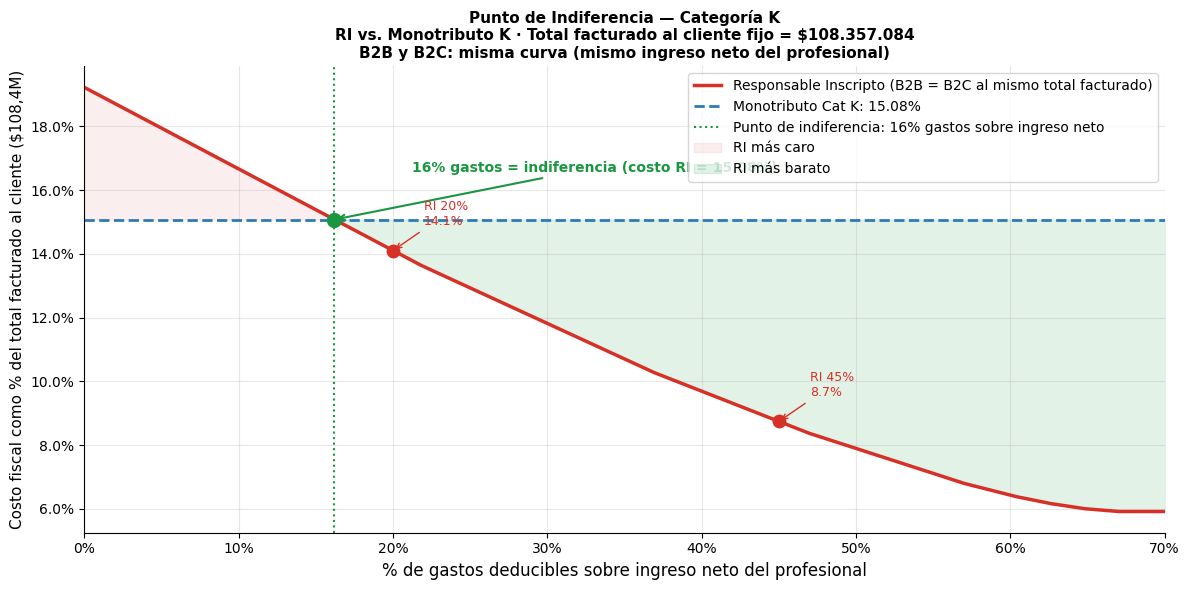

Gráfico guardado: indiferencia_cat_k.png


In [24]:
# ─────────────────────────────────────────────────────────────────────
# Curva de sensibilidad: costo RI vs. % gastos — Cat K total fijo $108M
# ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Curva RI (B2B y B2C, misma curva al fijar el mismo total al cliente)
ax.plot(pct_range * 100, ri_pcts, color='#D73027', lw=2.5,
        label='Responsable Inscripto (B2B = B2C al mismo total facturado)')

# Línea Monotributo K
ax.axhline(mono_pct, color='#2C7BB6', lw=2, linestyle='--',
           label=f'Monotributo Cat K: {mono_pct:.2f}%')

# Punto de indiferencia
if indiferencia_pct:
    ax.axvline(indiferencia_pct * 100, color='#1A9641', lw=1.5, linestyle=':',
               label=f'Punto de indiferencia: {indiferencia_pct:.0%} gastos sobre ingreso neto')
    ax.scatter([indiferencia_pct * 100], [indiferencia_val], s=100, color='#1A9641', zorder=6)
    ax.annotate(
        f'{indiferencia_pct:.0%} gastos = indiferencia (costo RI = {indiferencia_val:.2f}%)',
        xy=(indiferencia_pct * 100, indiferencia_val),
        xytext=(indiferencia_pct * 100 + 5, indiferencia_val + 1.5),
        fontsize=10, color='#1A9641', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#1A9641', lw=1.5)
    )

# Marcar 20% y 45%
for g, label_txt in [(0.20, '20%'), (0.45, '45%')]:
    v = ri_pcts[int(g * 10000 / 0.75)]  # approx index
    v = calcular_ri_b2c(TOTAL_REF_K, 'K', g)['pct_costo']
    ax.scatter([g * 100], [v], s=80, color='#D73027', zorder=6)
    ax.annotate(f'RI {label_txt}\n{v:.1f}%',
                xy=(g * 100, v), xytext=(g * 100 + 2, v + 0.8),
                fontsize=9, color='#D73027',
                arrowprops=dict(arrowstyle='->', color='#D73027', lw=1))

# Zonas coloreadas
ax.fill_between(pct_range * 100, ri_pcts, mono_pct,
                where=[v > mono_pct for v in ri_pcts],
                alpha=0.08, color='#D73027', label='RI más caro')
ax.fill_between(pct_range * 100, ri_pcts, mono_pct,
                where=[v <= mono_pct for v in ri_pcts],
                alpha=0.12, color='#1A9641', label='RI más barato')

ax.set_xlabel('% de gastos deducibles sobre ingreso neto del profesional', fontsize=12)
ax.set_ylabel('Costo fiscal como % del total facturado al cliente ($108,4M)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Punto de Indiferencia — Categoría K\n'
             'RI vs. Monotributo K · Total facturado al cliente fijo = $108.357.084\n'
             'B2B y B2C: misma curva (mismo ingreso neto del profesional)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 70)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('indiferencia_cat_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: indiferencia_cat_k.png')


### Resumen del punto de indiferencia — Cat K

Con un **total facturado al cliente de $108.357.084** (el límite de Cat K):

| | Monotributo K | RI (B2B y B2C) |
|---|---|---|
| Ingreso neto del profesional | $108.357.084 | $89.551.308 (= ÷ 1,21) |
| Punto de indiferencia | — | **~17% de gastos deducibles sobre ingreso neto** |
| Antes del punto (gastos <17%) | ✅ Conviene | ❌ Más caro |
| Después del punto (gastos >17%) | ❌ Más caro | ✅ Conviene |

**¿Por qué B2B = B2C en este análisis?**

Al fijar el mismo total al cliente ($108M), ambos tipos de cliente implican el mismo ingreso neto para el profesional ($89.6M), y por lo tanto el mismo Ganancias, el mismo SIPA y el mismo costo fiscal total. La diferencia B2B/B2C en términos fiscales del profesional desaparece cuando se normaliza el total al cliente.

La distinción B2B/B2C importa para:
- **Competitividad de precio**: el consumidor B2C paga IVA que no recupera
- **El comparativo con Monotributo**: el monotributista cobra $108M sin IVA, el RI cobra $89.6M neto + $18.8M IVA = $108M total

---
## 14. Punto de Indiferencia Cat H — B2B y B2C (mismo total al cliente)

Con total fijo = **$70.113.407** (límite Cat H), el ingreso neto del RI es $70.113.407 ÷ 1,21 = $57.944.139.

El costo mínimo posible del RI (con el 100% de gastos deducibles → Ganancias = $0) es solo SIPA + Contador.

In [25]:
# ─────────────────────────────────────────────────────────────────────
# Punto de indiferencia Cat H (mismo total al cliente = $70.113.407)
# ─────────────────────────────────────────────────────────────────────
TOTAL_REF_H = MONO['H']['billing_anual_max']   # $70.113.407
NET_FEE_RI_H = TOTAL_REF_H / (1 + IVA_RATE)   # $57.944.139

mono_pct_h = res_mono_h['pct_total_sin_os']    # 7.79%
mono_costo_h = res_mono_h['costo_total_sin_os']

# Costo mínimo absoluto del RI (Ganancias = 0)
costo_minimo_ri_h = AUTONOMOS_CAT_V_MES * 12 + RI_CONTADOR_ANUAL  # solo SIPA + contador
pct_minimo_ri_h = costo_minimo_ri_h / TOTAL_REF_H * 100

print(f"Total de referencia (Cat H):     {fmt_pesos(TOTAL_REF_H)}")
print(f"Ingreso neto RI (÷ 1,21):        {fmt_pesos(NET_FEE_RI_H)}")
print(f"Monotributo H costo total:       {fmt_pesos(mono_costo_h)}  ({mono_pct_h:.2f}%)")
print()
print(f"Costo mínimo RI (Ganancias=0):   {fmt_pesos(costo_minimo_ri_h)}  ({pct_minimo_ri_h:.2f}%)")
print(f"  = SIPA: {fmt_pesos(AUTONOMOS_CAT_V_MES*12)} + Contador: {fmt_pesos(RI_CONTADOR_ANUAL)}")
print()

if pct_minimo_ri_h > mono_pct_h:
    print(f"⚠️  CONCLUSIÓN: El RI NUNCA puede ser más barato que el Monotributo H")
    print(f"   incluso si el profesional no paga nada de Ganancias (gastos = 100%).")
    print()
    print(f"   Costo mínimo RI:  {pct_minimo_ri_h:.2f}%  (= SIPA + Contador, Ganancias = $0)")
    print(f"   Monotributo H:    {mono_pct_h:.2f}%")
    print(f"   Diferencia mínima: +{pct_minimo_ri_h - mono_pct_h:.2f}pp a favor del Monotributo")
    print()
    print("   Razón: el costo fijo del RI (SIPA + contador) supera el costo")
    print("   total del Monotributo H, independientemente de los gastos deducibles.")

# Curva para visualizar
pct_range_h = np.linspace(0, 0.99, 10000)
ri_pcts_h = []
for p in pct_range_h:
    gastos = NET_FEE_RI_H * p
    gni = max(NET_FEE_RI_H - gastos - RI_CONTADOR_ANUAL
              - AUTONOMOS_CAT_V_MES*12 - DEDUCCIONES_PERSONALES, 0)
    ganancias = calcular_ganancias(gni)
    costo_total = ganancias + AUTONOMOS_CAT_V_MES*12 + RI_CONTADOR_ANUAL
    ri_pcts_h.append(costo_total / TOTAL_REF_H * 100)


Total de referencia (Cat H):     $     70,113,407
Ingreso neto RI (÷ 1,21):        $     57,944,964
Monotributo H costo total:       $      5,458,332  (7.79%)

Costo mínimo RI (Ganancias=0):   $      6,407,208  (9.14%)
  = SIPA: $      3,407,208 + Contador: $      3,000,000

⚠️  CONCLUSIÓN: El RI NUNCA puede ser más barato que el Monotributo H
   incluso si el profesional no paga nada de Ganancias (gastos = 100%).

   Costo mínimo RI:  9.14%  (= SIPA + Contador, Ganancias = $0)
   Monotributo H:    7.79%
   Diferencia mínima: +1.35pp a favor del Monotributo

   Razón: el costo fijo del RI (SIPA + contador) supera el costo
   total del Monotributo H, independientemente de los gastos deducibles.


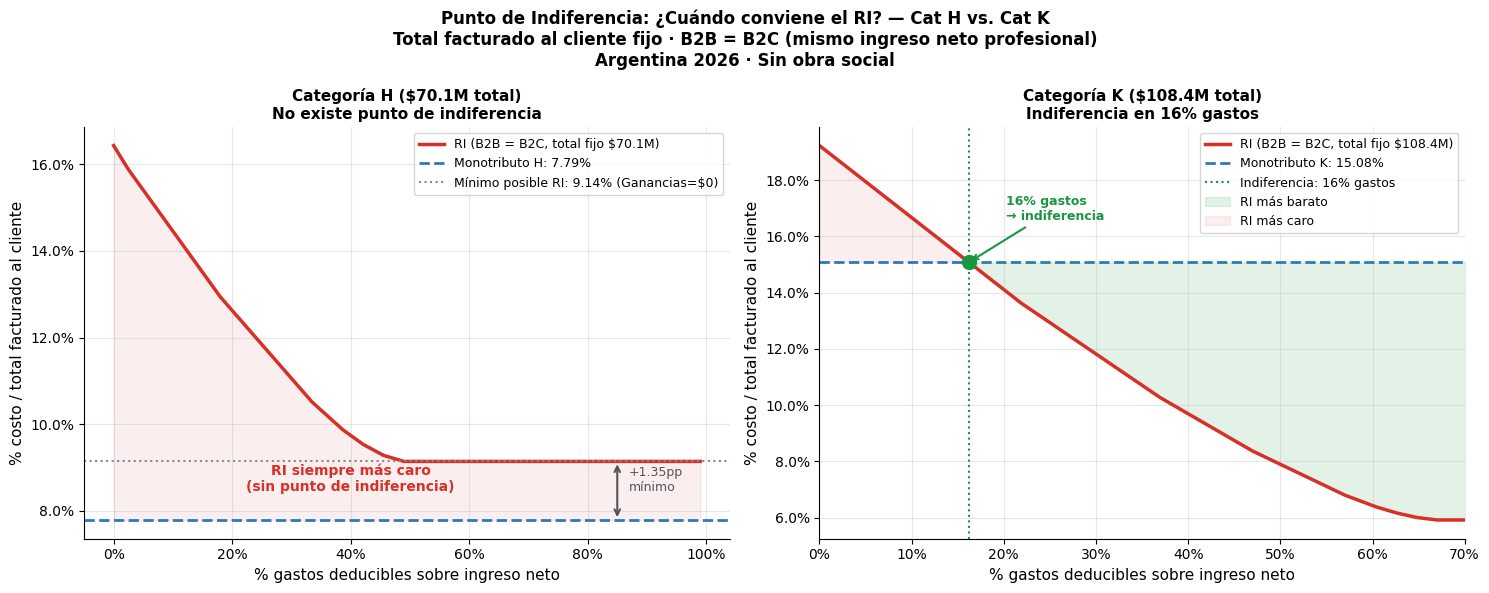

In [26]:
# ─────────────────────────────────────────────────────────────────────
# Gráfico: curva Cat H — RI nunca alcanza al Monotributo
# ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel izquierdo: Cat H ──
ax = axes[0]
ax.plot(pct_range_h * 100, ri_pcts_h, color='#D73027', lw=2.5,
        label='RI (B2B = B2C, total fijo $70.1M)')
ax.axhline(mono_pct_h, color='#2C7BB6', lw=2, linestyle='--',
           label=f'Monotributo H: {mono_pct_h:.2f}%')
ax.axhline(pct_minimo_ri_h, color='#888', lw=1.5, linestyle=':',
           label=f'Mínimo posible RI: {pct_minimo_ri_h:.2f}% (Ganancias=$0)')

# Zona de brecha mínima
ax.annotate('', xy=(85, pct_minimo_ri_h), xytext=(85, mono_pct_h),
            arrowprops=dict(arrowstyle='<->', color='#555', lw=1.5))
ax.text(87, (pct_minimo_ri_h + mono_pct_h)/2,
        f'+{pct_minimo_ri_h - mono_pct_h:.2f}pp\nmínimo', fontsize=9, color='#555')

ax.fill_between(pct_range_h * 100, ri_pcts_h, mono_pct_h,
                alpha=0.08, color='#D73027')
ax.text(40, (min(ri_pcts_h) + mono_pct_h)/2,
        'RI siempre más caro\n(sin punto de indiferencia)', fontsize=10,
        color='#D73027', ha='center', fontweight='bold')

ax.set_xlabel('% gastos deducibles sobre ingreso neto', fontsize=11)
ax.set_ylabel('% costo / total facturado al cliente', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Categoría H ($70.1M total)\nNo existe punto de indiferencia', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Panel derecho: Cat K (reutilizamos pct_range y ri_pcts del bloque anterior) ──
ax = axes[1]
ax.plot(pct_range * 100, ri_pcts, color='#D73027', lw=2.5,
        label='RI (B2B = B2C, total fijo $108.4M)')
ax.axhline(mono_pct, color='#2C7BB6', lw=2, linestyle='--',
           label=f'Monotributo K: {mono_pct:.2f}%')

if indiferencia_pct:
    ax.axvline(indiferencia_pct * 100, color='#1A9641', lw=1.5, linestyle=':',
               label=f'Indiferencia: {indiferencia_pct:.0%} gastos')
    ax.scatter([indiferencia_pct * 100], [indiferencia_val], s=100, color='#1A9641', zorder=6)
    ax.annotate(f'{indiferencia_pct:.0%} gastos\n→ indiferencia',
                xy=(indiferencia_pct * 100, indiferencia_val),
                xytext=(indiferencia_pct * 100 + 4, indiferencia_val + 1.5),
                fontsize=9, color='#1A9641', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#1A9641', lw=1.5))
    ax.fill_between(pct_range * 100, ri_pcts, mono_pct,
                    where=[v <= mono_pct for v in ri_pcts],
                    alpha=0.12, color='#1A9641', label='RI más barato')
    ax.fill_between(pct_range * 100, ri_pcts, mono_pct,
                    where=[v > mono_pct for v in ri_pcts],
                    alpha=0.08, color='#D73027', label='RI más caro')

ax.set_xlabel('% gastos deducibles sobre ingreso neto', fontsize=11)
ax.set_ylabel('% costo / total facturado al cliente', fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Categoría K ($108.4M total)\n'
             f'Indiferencia en {indiferencia_pct:.0%} gastos', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 70)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Punto de Indiferencia: ¿Cuándo conviene el RI? — Cat H vs. Cat K\n'
             'Total facturado al cliente fijo · B2B = B2C (mismo ingreso neto profesional)\n'
             'Argentina 2026 · Sin obra social',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('indiferencia_h_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()


### Comparativa de puntos de indiferencia — Cat H vs. Cat K

| | Cat H ($70.1M total) | Cat K ($108.4M total) |
|---|---|---|
| Ingreso neto RI (÷ 1,21) | $57.944.139 | $89.551.308 |
| Monotributo costo | **7,79%** ($5,46M) | **15,08%** ($16,34M) |
| Costo mínimo RI (Ganancias=0) | **9,14%** ($6,41M) | **5,92%** ($6,41M) |
| ¿Existe punto de indiferencia? | ❌ **No** | ✅ **Sí** |
| Punto de indiferencia | — | **~17% de gastos** sobre ingreso neto |

**¿Por qué Cat H no tiene punto de indiferencia?**

El costo fijo del RI (SIPA + contador = $6.41M/año) representa el **9,14%** del total de $70.1M. Como el Monotributo H cuesta solo el **7,79%**, el RI nunca puede igualarlo aunque el profesional tenga el 100% de sus ingresos como gastos deducibles y pague $0 de Ganancias.

**¿Por qué Cat K sí tiene punto de indiferencia?**

El alto impuesto integrado del Monotributo K ($14M/año) hace que su costo total (15,08%) supere fácilmente el costo fijo del RI (5,92% del total $108M). A partir de ~17% de gastos deducibles, Ganancias baja lo suficiente para que RI sea más barato.

---
## 15. Exportación a Excel Interactivo

Generación de un Excel con 4 hojas:
1. **Parámetros** — todas las variables del modelo (editables en amarillo)
2. **Resultados** — cuadro comparativo completo (10 escenarios)
3. **Sensibilidad** — tabla de % de costo vs. % de gastos (0% a 75%)
4. **Mi Escenario** — hoja personalizable donde podés ingresar tu facturación y gastos reales y obtener la recomendación automáticamente

In [27]:
# ─────────────────────────────────────────────────────────────────────
# Generación del Excel interactivo con parámetros editables
# ─────────────────────────────────────────────────────────────────────
from openpyxl import Workbook
from openpyxl.styles import (Font, PatternFill, Alignment, Border, Side,
                              numbers)
from openpyxl.utils import get_column_letter
from openpyxl.formatting.rule import ColorScaleRule
import openpyxl.styles.numbers as opnums

wb = Workbook()

# ────────── Paleta de colores ──────────
AZUL_OSC   = "1F3864"
AZUL_MED   = "2C7BB6"
AZUL_CLARO = "DEEAF1"
VERDE_OSC  = "1A5C2A"
VERDE_CLAR = "E2EFDA"
AMARILLO   = "FFF2CC"
NARANJA    = "FCE4D6"
GRIS_CLAR  = "F2F2F2"
BLANCO     = "FFFFFF"

def fill(hex_col):
    return PatternFill("solid", fgColor=hex_col)

def border_thin():
    s = Side(style="thin", color="BBBBBB")
    return Border(left=s, right=s, top=s, bottom=s)

def border_medium():
    s = Side(style="medium", color="888888")
    return Border(left=s, right=s, top=s, bottom=s)

def header_style(ws, row, col, text, bg=AZUL_OSC, fg=BLANCO, bold=True, size=11):
    cell = ws.cell(row=row, column=col, value=text)
    cell.font = Font(bold=bold, color=fg, size=size)
    cell.fill = fill(bg)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border = border_thin()
    return cell

def label_cell(ws, row, col, text, bold=False, bg=GRIS_CLAR):
    cell = ws.cell(row=row, column=col, value=text)
    cell.font = Font(bold=bold, size=10)
    cell.fill = fill(bg)
    cell.alignment = Alignment(horizontal="left", vertical="center")
    cell.border = border_thin()
    return cell

def input_cell(ws, row, col, value, fmt=None, bg=AMARILLO):
    cell = ws.cell(row=row, column=col, value=value)
    cell.fill = fill(bg)
    cell.font = Font(bold=True, color="7B3F00", size=10)
    cell.alignment = Alignment(horizontal="right", vertical="center")
    cell.border = border_medium()
    if fmt:
        cell.number_format = fmt
    return cell

def result_cell(ws, row, col, formula_or_val, fmt=None, bg=BLANCO, bold=False, color="000000"):
    cell = ws.cell(row=row, column=col, value=formula_or_val)
    cell.fill = fill(bg)
    cell.font = Font(bold=bold, color=color, size=10)
    cell.alignment = Alignment(horizontal="right", vertical="center")
    cell.border = border_thin()
    if fmt:
        cell.number_format = fmt
    return cell

PESO = '#,##0'
PCT  = '0.00%'
PCT1 = '0.0%'

# ══════════════════════════════════════════════════════════════════════
# HOJA 1: PARÁMETROS
# ══════════════════════════════════════════════════════════════════════
ws_p = wb.active
ws_p.title = "Parámetros"
ws_p.column_dimensions['A'].width = 38
ws_p.column_dimensions['B'].width = 20
ws_p.column_dimensions['C'].width = 22
ws_p.column_dimensions['D'].width = 40
ws_p.row_dimensions[1].height = 30

header_style(ws_p, 1, 1, "PARÁMETROS DEL MODELO FISCAL — ARGENTINA 2026", bg=AZUL_OSC, size=12)
ws_p.merge_cells('A1:D1')
ws_p.cell(row=1, column=1).alignment = Alignment(horizontal="center", vertical="center")

# Subtítulo
ws_p.cell(row=2, column=1, value="Celdas amarillas = editables. Los resultados se recalculan automáticamente.")
ws_p.cell(row=2, column=1).font = Font(italic=True, color="555555", size=9)
ws_p.merge_cells('A2:D2')

def section_header(row, text):
    c = ws_p.cell(row=row, column=1, value=text)
    c.font = Font(bold=True, color=BLANCO, size=10)
    c.fill = fill(AZUL_MED)
    c.border = border_thin()
    for col in range(2, 5):
        ws_p.cell(row=row, column=col).fill = fill(AZUL_MED)
        ws_p.cell(row=row, column=col).border = border_thin()

def param_row(row, label, value, fmt, nota=""):
    label_cell(ws_p, row, 1, label)
    input_cell(ws_p, row, 2, value, fmt)
    ws_p.cell(row=row, column=3).border = border_thin()
    ws_p.cell(row=row, column=3).fill = fill(BLANCO)
    c = ws_p.cell(row=row, column=4, value=nota)
    c.font = Font(italic=True, color="666666", size=9)
    c.fill = fill(BLANCO)
    c.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
    c.border = border_thin()

r = 4
section_header(r, "── MONOTRIBUTO (1er semestre 2026, servicios) ──")
r+=1; param_row(r, "Billing máx. Cat H (anual)", 70113407, PESO, "Límite ingresos Cat H · Feb 2026")
r+=1; param_row(r, "Billing máx. Cat K (anual)", 108357084, PESO, "Límite ingresos Cat K · Feb 2026")
r+=1; param_row(r, "Impuesto integrado Cat H (anual)", 4206804, PESO, "Componente impositivo cuota Cat H")
r+=1; param_row(r, "Impuesto integrado Cat K (anual)", 14054556, PESO, "Componente impositivo cuota Cat K")
r+=1; param_row(r, "SIPA jubilación Cat H (anual)", 829128, PESO, "Componente previsional Cat H")
r+=1; param_row(r, "SIPA jubilación Cat K (anual)", 829128, PESO, "Componente previsional Cat K")
r+=1; param_row(r, "Honorarios contador Monotributo (anual)", 660000, PESO, "$55.000/mes")

BIL_H  = f"B{4+1}"; BIL_K  = f"B{4+2}"
IMP_H  = f"B{4+3}"; IMP_K  = f"B{4+4}"
SIPA_H = f"B{4+5}"; SIPA_K = f"B{4+6}"
CNT_M  = f"B{4+7}"

r+=2
section_header(r, "── RESPONSABLE INSCRIPTO ──")
r+=1; param_row(r, "Tasa IVA", 0.21, PCT, "Alícuota general 21%")
r+=1; param_row(r, "Aportes autónomos Cat V (mensual)", 283934, PESO, "Incluye SIPA + obra social · Feb 2026")
r+=1; param_row(r, "Fracción SIPA (jubilación)", 0.60, PCT, "~60% del aporte total va a jubilación")
r+=1; param_row(r, "Honorarios contador RI (anual)", 3000000, PESO, "Estimado por mayor complejidad del régimen")
r+=1; param_row(r, "% Gastos deducibles — Escenario A", 0.20, PCT, "Gastos profesionales / ingreso neto")
r+=1; param_row(r, "% Gastos deducibles — Escenario B", 0.45, PCT, "Profesional con alta estructura de costos")

IVA_R  = f"B{r-5}"; AUT_M  = f"B{r-4}"; FSIPA  = f"B{r-3}"
CNT_RI = f"B{r-2}"; GAS_A  = f"B{r-1}"; GAS_B  = f"B{r}"

r+=2
section_header(r, "── DEDUCCIONES PERSONALES GANANCIAS (anual) ──")
r+=1; param_row(r, "Mínimo No Imponible (MNI)", 13677828, PESO, "Soltero sin cargas · 2026")
r+=1; param_row(r, "Deducción Especial (DE) servicios", 9505236, PESO, "Profesional / autónomo")

MNI_R = f"B{r-1}"; DE_R = f"B{r}"
DED_TOTAL = f"({MNI_R}+{DE_R})"

r+=2
section_header(r, "── ESCALA GANANCIAS (1er semestre 2026) ──")
r+=1
header_style(ws_p, r, 1, "Desde ($)", bg=AZUL_CLARO, fg="000000", size=9)
header_style(ws_p, r, 2, "Hasta ($)", bg=AZUL_CLARO, fg="000000", size=9)
header_style(ws_p, r, 3, "Cuota fija ($)", bg=AZUL_CLARO, fg="000000", size=9)
header_style(ws_p, r, 4, "% s/ excedente", bg=AZUL_CLARO, fg="000000", size=9)

escala = [
    (0,          3000045,   0,        5),
    (3000045,    6000090,   150002,   9),
    (6000090,    9000135,   420008,   12),
    (9000135,   18000271,   780015,   15),   # bracket corregido
    (18000271,  27000406,  2115040,   19),
    (27000406,  40500609,  3825052,   23),
    (40500609,  54000812,  6930094,   27),
    (54000812,  81001218, 10575143,   31),
    (81001218,  None,     18954524,   35),
]
ESC_ROW0 = r + 1
for desde, hasta, cuota, alicuota in escala:
    r += 1
    result_cell(ws_p, r, 1, desde, PESO, bg=BLANCO)
    result_cell(ws_p, r, 2, hasta if hasta else 9999999999, PESO, bg=BLANCO)
    result_cell(ws_p, r, 3, cuota, PESO, bg=BLANCO)
    result_cell(ws_p, r, 4, alicuota/100, PCT, bg=BLANCO)

ESC_ROW_END = r
P_ESC_DESDE = f"A{ESC_ROW0}:A{ESC_ROW_END}"
P_ESC_HASTA = f"B{ESC_ROW0}:B{ESC_ROW_END}"
P_ESC_CUOTA = f"C{ESC_ROW0}:C{ESC_ROW_END}"
P_ESC_ALIC  = f"D{ESC_ROW0}:D{ESC_ROW_END}"

# Nombrar rangos para usar en Resultados
from openpyxl.workbook.defined_name import DefinedName

def def_name(wb, name, ref):
    dn = DefinedName(name, attr_text=ref)
    wb.defined_names[name] = dn

def_name(wb, "BIL_H",  f"Parámetros!${BIL_H}")
def_name(wb, "BIL_K",  f"Parámetros!${BIL_K}")
def_name(wb, "IMP_H",  f"Parámetros!${IMP_H}")
def_name(wb, "IMP_K",  f"Parámetros!${IMP_K}")
def_name(wb, "SIPAM_H",f"Parámetros!${SIPA_H}")
def_name(wb, "SIPAM_K",f"Parámetros!${SIPA_K}")
def_name(wb, "CNT_M",  f"Parámetros!${CNT_M}")
def_name(wb, "IVA_R",  f"Parámetros!${IVA_R}")
def_name(wb, "AUT_M",  f"Parámetros!${AUT_M}")
def_name(wb, "FSIPA",  f"Parámetros!${FSIPA}")
def_name(wb, "CNT_RI", f"Parámetros!${CNT_RI}")
def_name(wb, "GAS_A",  f"Parámetros!${GAS_A}")
def_name(wb, "GAS_B",  f"Parámetros!${GAS_B}")
def_name(wb, "MNI_R",  f"Parámetros!${MNI_R}")
def_name(wb, "DE_R",   f"Parámetros!${DE_R}")

print(f"Hoja Parámetros: {r} filas")

# ══════════════════════════════════════════════════════════════════════
# HOJA 2: RESULTADOS
# ══════════════════════════════════════════════════════════════════════
ws_r = wb.create_sheet("Resultados")
for col, w in zip(['A','B','C','D','E','F','G','H'],
                  [35, 18, 18, 18, 18, 18, 18, 18]):
    ws_r.column_dimensions[col].width = w

ws_r.row_dimensions[1].height = 32
header_style(ws_r, 1, 1, "RESULTADOS — Monotributo vs. Responsable Inscripto · Argentina 2026", bg=AZUL_OSC, size=12)
ws_r.merge_cells('A1:H1')

# Subtitulo columnas
header_style(ws_r, 3, 1, "Concepto", bg=AZUL_MED)
header_style(ws_r, 3, 2, "Mono H", bg=AZUL_MED)
header_style(ws_r, 3, 3, "RI H\nB2B — 20% g.", bg=AZUL_MED)
header_style(ws_r, 3, 4, "RI H\nB2B — 45% g.", bg=AZUL_MED)
header_style(ws_r, 3, 5, "RI H\nB2C — 20% g.", bg=AZUL_MED)
header_style(ws_r, 3, 6, "RI H\nB2C — 45% g.", bg=AZUL_MED)
header_style(ws_r, 3, 7, "Mono K", bg=AZUL_MED)
# Segunda fila de cabecera para K — merge
for col in range(2, 9):
    ws_r.row_dimensions[3].height = 30

# Nota de referencia
c = ws_r.cell(row=2, column=1, value="Total de referencia = billing del Monotributo (H o K). Para RI, incluye IVA en el total al cliente.")
c.font = Font(italic=True, color="555555", size=9)
ws_r.merge_cells('A2:H2')

# Helper: fórmula Ganancias vía MATCH/INDEX sobre la escala de Parámetros
def ganancias_formula(gni_formula: str) -> str:
    """Devuelve fórmula Excel que calcula Ganancias sobre un GNI dado."""
    esc_d = f"Parámetros!$A${ESC_ROW0}:$A${ESC_ROW_END}"
    esc_h = f"Parámetros!$B${ESC_ROW0}:$B${ESC_ROW_END}"
    esc_c = f"Parámetros!$C${ESC_ROW0}:$C${ESC_ROW_END}"
    esc_a = f"Parámetros!$D${ESC_ROW0}:$D${ESC_ROW_END}"
    # MATCH busca el tramo: último tramo donde GNI >= Desde
    return (f"MAX(0,IFERROR(INDEX({esc_c},MATCH({gni_formula},{esc_d},1))"
            f"+INDEX({esc_a},MATCH({gni_formula},{esc_d},1))"
            f"*({gni_formula}-INDEX({esc_d},MATCH({gni_formula},{esc_d},1))),0))")

rows_data = [
    # (label, nota_color)
    ("── FACTURACIÓN ──",            AZUL_MED),
    ("Total facturado al cliente",   None),
    ("Ingreso neto del profesional", None),
    ("IVA cobrado al cliente",       None),
    ("── DEDUCCIONES RI (Ganancias) ──", AZUL_MED),
    ("Gastos deducibles (% ingreso)", None),
    ("Aportes autónomos (anual)",    None),
    ("Honorarios contador",          None),
    ("Deducciones personales",       None),
    ("Ganancia Neta Imponible",      VERDE_CLAR),
    ("── IMPUESTOS Y CARGAS ──",    AZUL_MED),
    ("Impuesto (integrado/Ganancias)", None),
    ("SIPA jubilación",              None),
    ("Honorarios contador",          None),
    ("── TOTALES ──",               AZUL_MED),
    ("COSTO TOTAL (sin OS)",         NARANJA),
    ("% sobre TOTAL FACTURADO",      NARANJA),
    ("Diferencia vs. Monotributo ($)", None),
    ("Diferencia vs. Monotributo (pp)", None),
]

# Referencias a Parámetros
P = "Parámetros!"

# Cada columna: (billing_ref, iva_en_billing, pct_gastos_ref, es_ri)
# Columna 2: Mono H
# Columna 3: RI H B2B 20% — billing_neto=BIL_H, total=BIL_H*(1+IVA), gastos=GAS_A
# Columna 4: RI H B2B 45% — gastos=GAS_B
# Columna 5: RI H B2C 20% — total=BIL_H, net=BIL_H/(1+IVA), gastos=GAS_A
# Columna 6: RI H B2C 45%
# Columna 7: Mono K
# Columna 8: RI K B2B 20%

# Vamos a escribir valores calculados (las fórmulas Excel con MATCH son complejas)
# Usamos fórmulas Python para calcular los valores y los ponemos como fórmulas
# con referencias a Parámetros cuando sea posible, y valores directos para Ganancias.

import sys
sys.path.insert(0, '/home/user/analisis-fiscal')

# Recalcular todo con los parámetros actuales
MONO_DATA = {
    'H': {'billing': 70113407, 'imp': 4206804, 'sipa': 829128, 'cnt': 660000},
    'K': {'billing': 108357084, 'imp': 14054556, 'sipa': 829128, 'cnt': 660000},
}

import numpy as np

ESCALA_GANANCIAS = [
    (0,         3000045,   0,        0.05),
    (3000045,   6000090,   150002,   0.09),
    (6000090,   9000135,   420008,   0.12),
    (9000135,  18000271,   780015,   0.15),
    (18000271, 27000406,  2115040,   0.19),
    (27000406, 40500609,  3825052,   0.23),
    (40500609, 54000812,  6930094,   0.27),
    (54000812, 81001218, 10575143,   0.31),
    (81001218, float('inf'), 18954524, 0.35),
]

def calc_ganancias(gni):
    for desde, hasta, cuota, alicuota in ESCALA_GANANCIAS:
        if gni <= hasta:
            return cuota + alicuota * (gni - desde)
    return 0

AUT_ANUAL = 283934 * 12
SIPA_FRAC = 0.60
SIPA_ANUAL = AUT_ANUAL * SIPA_FRAC
CONT_RI = 3000000
DED_PERS = 13677828 + 9505236
IVA_RATE_V = 0.21

def calc_ri(billing_neto, pct_g):
    gastos = billing_neto * pct_g
    gni    = max(billing_neto - gastos - CONT_RI - AUT_ANUAL - DED_PERS, 0)
    gan    = calc_ganancias(gni)
    costo  = gan + SIPA_ANUAL + CONT_RI
    return gni, gan, costo

def scenario(billing_ref, pct_g, b2c=False, mono_cat=None):
    if mono_cat:
        d = MONO_DATA[mono_cat]
        total = d['billing']
        net   = d['billing']
        iva   = 0
        gastos_deducibles = 0
        gni   = 0
        gan   = d['imp']
        sipa  = d['sipa']
        cnt   = d['cnt']
        costo = gan + sipa + cnt
    else:
        if b2c:
            total = billing_ref
            net   = billing_ref / (1 + IVA_RATE_V)
        else:  # B2B
            net   = billing_ref
            total = billing_ref * (1 + IVA_RATE_V)
        iva   = total - net
        gastos_deducibles = net * pct_g
        gni, gan, costo = calc_ri(net, pct_g)
        sipa  = SIPA_ANUAL
        cnt   = CONT_RI
    return {
        'total': total, 'net': net, 'iva': iva,
        'gastos': gastos_deducibles,
        'aut': AUT_ANUAL if mono_cat is None else 0,
        'cnt': cnt,
        'ded': DED_PERS if mono_cat is None else 0,
        'gni': gni,
        'gan': gan,
        'sipa': sipa,
        'costo': costo,
        'pct': costo / total * 100,
    }

BIL_H_V = MONO_DATA['H']['billing']
BIL_K_V = MONO_DATA['K']['billing']

cols = [
    scenario(BIL_H_V, 0,    mono_cat='H'),         # C2: Mono H
    scenario(BIL_H_V, 0.20, b2c=False),             # C3: RI H B2B 20%
    scenario(BIL_H_V, 0.45, b2c=False),             # C4: RI H B2B 45%
    scenario(BIL_H_V, 0.20, b2c=True),              # C5: RI H B2C 20%
    scenario(BIL_H_V, 0.45, b2c=True),              # C6: RI H B2C 45%
    scenario(BIL_K_V, 0,    mono_cat='K'),           # C7: Mono K
    scenario(BIL_K_V, 0.20, b2c=False),             # C8: RI K B2B 20%
    scenario(BIL_K_V, 0.45, b2c=False),             # C9: RI K B2B 45%
    scenario(BIL_K_V, 0.20, b2c=True),              # C10: RI K B2C 20%
    scenario(BIL_K_V, 0.45, b2c=True),              # C11: RI K B2C 45%
]

# Agregar más columnas para K
header_style(ws_r, 3, 8, "RI K\nB2B — 20% g.", bg=AZUL_MED)
header_style(ws_r, 3, 9, "RI K\nB2B — 45% g.", bg=AZUL_MED)
header_style(ws_r, 3, 10, "RI K\nB2C — 20% g.", bg=AZUL_MED)
header_style(ws_r, 3, 11, "RI K\nB2C — 45% g.", bg=AZUL_MED)
header_style(ws_r, 3, 7, "Mono K", bg=AZUL_MED)
ws_r.column_dimensions['I'].width = 18
ws_r.column_dimensions['J'].width = 18
ws_r.column_dimensions['K'].width = 18

row_labels_fmt = [
    # (key, fmt, bg_override)
    ("──",    None,  AZUL_CLARO),
    ("total", PESO,  None),
    ("net",   PESO,  None),
    ("iva",   PESO,  None),
    ("──",    None,  AZUL_CLARO),
    ("gastos",PESO,  None),
    ("aut",   PESO,  None),
    ("cnt",   PESO,  None),
    ("ded",   PESO,  None),
    ("gni",   PESO,  VERDE_CLAR),
    ("──",    None,  AZUL_CLARO),
    ("gan",   PESO,  None),
    ("sipa",  PESO,  None),
    ("cnt",   PESO,  None),
    ("──",    None,  AZUL_CLARO),
    ("costo", PESO,  NARANJA),
    ("pct",   '0.00"%"', NARANJA),
    ("diff$", PESO,  None),
    ("diffpp",'0.00"%"', None),
]

ROW_START = 4
for i, (label, nota_bg) in enumerate(rows_data):
    row = ROW_START + i
    ws_r.row_dimensions[row].height = 18
    key, fmt, bg_ov = row_labels_fmt[i]
    is_header = (key == "──")
    lbl_bg = AZUL_CLARO if is_header else GRIS_CLAR
    c = ws_r.cell(row=row, column=1, value=label)
    c.font = Font(bold=is_header, color=BLANCO if is_header else "000000", size=10)
    c.fill = fill(AZUL_CLARO if is_header else GRIS_CLAR)
    c.border = border_thin()
    c.alignment = Alignment(horizontal="left", vertical="center")

    for j, sc in enumerate(cols):
        col = j + 2
        if is_header:
            ws_r.cell(row=row, column=col).fill = fill(AZUL_CLARO)
            ws_r.cell(row=row, column=col).border = border_thin()
            continue
        if key in ("diff$", "diffpp"):
            # Diferencia vs Monotributo de la misma categoría
            if j == 0 or j == 5:  # son los Monotributos, no aplica
                val = None
            else:
                mono_idx = 0 if j < 5 else 5
                if key == "diff$":
                    val = sc['costo'] - cols[mono_idx]['costo']
                else:
                    val = sc['pct'] - cols[mono_idx]['pct']
        elif key == "pct":
            val = sc['pct'] / 100
            fmt = PCT
        elif key == "cnt":
            val = sc.get('cnt', 0)
        else:
            val = sc.get(key, 0) or 0
        
        bg = bg_ov or BLANCO
        bold = key in ("costo", "pct", "gni")
        color_txt = "000000"
        if key == "pct" and val is not None:
            color_txt = VERDE_OSC if sc['pct'] <= (cols[0 if j<5 else 5]['pct']) else "8B0000"
        if key in ("diff$", "diffpp") and val is not None and val < 0:
            color_txt = VERDE_OSC
        result_cell(ws_r, row, col, val, fmt, bg, bold, color_txt)

# Freeze panes
ws_r.freeze_panes = "B4"
print(f"Hoja Resultados: {len(cols)} escenarios")

# ══════════════════════════════════════════════════════════════════════
# HOJA 3: SENSIBILIDAD
# ══════════════════════════════════════════════════════════════════════
ws_s = wb.create_sheet("Sensibilidad")
ws_s.column_dimensions['A'].width = 22
for col in ['B','C','D','E']:
    ws_s.column_dimensions[col].width = 18

header_style(ws_s, 1, 1, "ANÁLISIS DE SENSIBILIDAD — % Gastos Deducibles vs. Costo Fiscal", bg=AZUL_OSC, size=11)
ws_s.merge_cells('A1:E1')

header_style(ws_s, 2, 1, "% Gastos\n(s/ ing. neto)", bg=AZUL_MED)
header_style(ws_s, 2, 2, "RI H B2B/B2C\n% costo/total", bg=AZUL_MED)
header_style(ws_s, 2, 3, "Mono H\n(referencia)", bg="2C7BB6")
header_style(ws_s, 2, 4, "RI K B2B/B2C\n% costo/total", bg=AZUL_MED)
header_style(ws_s, 2, 5, "Mono K\n(referencia)", bg="2C7BB6")

mono_h_pct = cols[0]['pct'] / 100
mono_k_pct = cols[5]['pct'] / 100

for row_i, pct_g in enumerate(range(0, 76, 5)):
    row = row_i + 3
    p = pct_g / 100

    sc_h = scenario(BIL_H_V, p, b2c=True)
    sc_k = scenario(BIL_K_V, p, b2c=True)
    v_h = sc_h['pct'] / 100
    v_k = sc_k['pct'] / 100

    c_pct = ws_s.cell(row=row, column=1, value=p)
    c_pct.number_format = PCT
    c_pct.fill = fill(GRIS_CLAR)
    c_pct.border = border_thin()
    c_pct.alignment = Alignment(horizontal="center")

    for col, val, mono_ref in [(2, v_h, mono_h_pct), (4, v_k, mono_k_pct)]:
        c = result_cell(ws_s, row, col, val, PCT, bg=VERDE_CLAR if val <= mono_ref else NARANJA)
        c.font = Font(bold=(abs(val - mono_ref) < 0.005),
                      color=VERDE_OSC if val <= mono_ref else "8B0000", size=10)

    result_cell(ws_s, row, 3, mono_h_pct, PCT, bg=AZUL_CLARO)
    result_cell(ws_s, row, 5, mono_k_pct, PCT, bg=AZUL_CLARO)

ws_s.freeze_panes = "A3"
print("Hoja Sensibilidad creada")

# ══════════════════════════════════════════════════════════════════════
# HOJA 4: MI ESCENARIO (personalizable)
# ══════════════════════════════════════════════════════════════════════
ws_m = wb.create_sheet("Mi Escenario")
ws_m.column_dimensions['A'].width = 38
ws_m.column_dimensions['B'].width = 22
ws_m.column_dimensions['C'].width = 18
ws_m.column_dimensions['D'].width = 35
ws_m.row_dimensions[1].height = 30

header_style(ws_m, 1, 1, "MI ESCENARIO PERSONALIZADO", bg=AZUL_OSC, size=12)
ws_m.merge_cells('A1:D1')

c = ws_m.cell(row=2, column=1, value="Ingresá tus valores para comparar tu situación particular.")
c.font = Font(italic=True, color="555555", size=9)
ws_m.merge_cells('A2:D2')

def mi_section(row, text):
    c = ws_m.cell(row=row, column=1, value=text)
    c.font = Font(bold=True, color=BLANCO, size=10)
    c.fill = fill(AZUL_MED)
    c.border = border_thin()
    ws_m.merge_cells(f'A{row}:D{row}')

def mi_input(row, label, value, fmt, nota=""):
    label_cell(ws_m, row, 1, label, bg=GRIS_CLAR)
    input_cell(ws_m, row, 2, value, fmt)
    c = ws_m.cell(row=row, column=3)
    c.fill = fill(BLANCO); c.border = border_thin()
    cn = ws_m.cell(row=row, column=4, value=nota)
    cn.font = Font(italic=True, color="666666", size=9)
    cn.fill = fill(BLANCO)
    cn.alignment = Alignment(wrap_text=True)
    cn.border = border_thin()

r = 4
mi_section(r, "── TUS DATOS ──")
r+=1; mi_input(r, "Facturación mensual promedio ($)",  8000000,  PESO, "Lo que facturás en promedio por mes")
r+=1; mi_input(r, "% Gastos deducibles (sobre ing. neto)", 0.25, PCT, "Tus costos reales como % de tus ingresos")
r+=1; mi_input(r, "Tipo de clientes",                  "B2B",    None, "Escribí B2B o B2C")

FAC_MES  = f"B{r-2}"
GAS_MIO  = f"B{r-1}"
TIPO_CLI = f"B{r}"

# Cálculos
r+=2
mi_section(r, "── CÁLCULOS ──")
r+=1; label_cell(ws_m, r, 1, "Facturación anual (billing ref.)")
result_cell(ws_m, r, 2, f"={FAC_MES}*12", PESO, AZUL_CLARO, bold=True)
FAC_ANUAL = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')
ws_m.cell(row=r, column=3).border = border_thin()

r+=1; label_cell(ws_m, r, 1, "IVA rate (de Parámetros)")
result_cell(ws_m, r, 2, "=IVA_R", PCT, AZUL_CLARO)
IVA_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Ingreso neto RI (÷ 1+IVA)")
result_cell(ws_m, r, 2, f"={FAC_ANUAL}/(1+{IVA_F})", PESO, AZUL_CLARO)
NET_MIO = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Gastos deducibles ($)")
result_cell(ws_m, r, 2, f"={NET_MIO}*{GAS_MIO}", PESO, AZUL_CLARO)
GAS_MIO_PESOS = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Aportes autónomos anuales")
result_cell(ws_m, r, 2, "=AUT_M*12", PESO, AZUL_CLARO)
AUT_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Deducciones personales")
result_cell(ws_m, r, 2, "=MNI_R+DE_R", PESO, AZUL_CLARO)
DED_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Ganancia Neta Imponible (GNI)", bold=True)
result_cell(ws_m, r, 2, f"=MAX(0,{NET_MIO}-{GAS_MIO_PESOS}-CNT_RI-{AUT_F}-{DED_F})", PESO, VERDE_CLAR, bold=True)
GNI_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=2
mi_section(r, "── COSTO RI ──")
r+=1; label_cell(ws_m, r, 1, "Impuesto a las Ganancias")
# Ganancias vía MATCH/INDEX sobre la escala
g_formula = (f"=MAX(0,IFERROR(INDEX(Parámetros!$C${ESC_ROW0}:$C${ESC_ROW_END},"
             f"MATCH({GNI_F},Parámetros!$A${ESC_ROW0}:$A${ESC_ROW_END},1))"
             f"+INDEX(Parámetros!$D${ESC_ROW0}:$D${ESC_ROW_END},"
             f"MATCH({GNI_F},Parámetros!$A${ESC_ROW0}:$A${ESC_ROW_END},1))"
             f"*({GNI_F}-INDEX(Parámetros!$A${ESC_ROW0}:$A${ESC_ROW_END},"
             f"MATCH({GNI_F},Parámetros!$A${ESC_ROW0}:$A${ESC_ROW_END},1))),0))")
result_cell(ws_m, r, 2, g_formula, PESO, BLANCO)
GAN_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "SIPA jubilación")
result_cell(ws_m, r, 2, f"=AUT_M*12*FSIPA", PESO, BLANCO)
SIPA_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Honorarios contador RI")
result_cell(ws_m, r, 2, "=CNT_RI", PESO, BLANCO)
CNT_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "COSTO TOTAL RI (sin OS)", bold=True)
result_cell(ws_m, r, 2, f"={GAN_F}+{SIPA_F}+{CNT_F}", PESO, NARANJA, bold=True)
COSTO_RI_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "% sobre total facturado", bold=True)
result_cell(ws_m, r, 2, f"={COSTO_RI_F}/{FAC_ANUAL}", PCT, NARANJA, bold=True)
PCT_RI_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=2
mi_section(r, "── COSTO MONOTRIBUTO (estimado por facturación) ──")
r+=1; label_cell(ws_m, r, 1, "Impuesto integrado (interpolado)")
# Simplificado: interpolación lineal entre H y K
result_cell(ws_m, r, 2,
    f"=IF({FAC_ANUAL}<=BIL_H, IMP_H*({FAC_ANUAL}/BIL_H),"
    f"IF({FAC_ANUAL}<=BIL_K, IMP_H+(IMP_K-IMP_H)*(({FAC_ANUAL}-BIL_H)/(BIL_K-BIL_H)), IMP_K))",
    PESO, BLANCO)
IMP_EST_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')
ws_m.cell(row=r, column=3).value = "(interpolado entre Cat H y K)"
ws_m.cell(row=r, column=3).font = Font(italic=True, color="666666", size=9)

r+=1; label_cell(ws_m, r, 1, "SIPA jubilación Monotributo")
result_cell(ws_m, r, 2, "=SIPAM_H", PESO, BLANCO)
SIPAM_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "Honorarios contador Mono")
result_cell(ws_m, r, 2, "=CNT_M", PESO, BLANCO)
CNTM_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "COSTO TOTAL Monotributo (sin OS)", bold=True)
result_cell(ws_m, r, 2, f"={IMP_EST_F}+{SIPAM_F}+{CNTM_F}", PESO, NARANJA, bold=True)
COSTO_M_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=1; label_cell(ws_m, r, 1, "% sobre total facturado", bold=True)
result_cell(ws_m, r, 2, f"={COSTO_M_F}/{FAC_ANUAL}", PCT, NARANJA, bold=True)
PCT_M_F = f"B{r}"
ws_m.merge_cells(f'C{r}:D{r}')

r+=2
mi_section(r, "── RECOMENDACIÓN ──")
r+=1
label_cell(ws_m, r, 1, "Régimen más conveniente", bold=True)
rec = ws_m.cell(row=r, column=2,
    value=f'=IF({PCT_RI_F}<{PCT_M_F},"✅ Responsable Inscripto","✅ Monotributo")')
rec.font = Font(bold=True, size=12, color=VERDE_OSC)
rec.fill = fill(VERDE_CLAR)
rec.border = border_medium()
rec.alignment = Alignment(horizontal="center", vertical="center")
ws_m.merge_cells(f'B{r}:D{r}')

r+=1
label_cell(ws_m, r, 1, "Diferencia (RI - Mono) en $ anuales")
result_cell(ws_m, r, 2, f"={COSTO_RI_F}-{COSTO_M_F}", PESO, BLANCO)
ws_m.merge_cells(f'C{r}:D{r}')

r+=1
label_cell(ws_m, r, 1, "Diferencia (RI - Mono) en pp")
result_cell(ws_m, r, 2, f"=({PCT_RI_F}-{PCT_M_F})*100", '0.00', BLANCO)
ws_m.merge_cells(f'C{r}:D{r}')

ws_m.freeze_panes = "A4"

# Guardar
path = '/home/user/analisis-fiscal/simulador_fiscal_argentina_2026.xlsx'
wb.save(path)
print(f"Excel guardado: {path}")


Hoja Parámetros: 35 filas
Hoja Resultados: 10 escenarios
Hoja Sensibilidad creada
Excel guardado: /home/user/analisis-fiscal/simulador_fiscal_argentina_2026.xlsx
